# TestMultilabelData — skeletonize & reconnect a random multilabel case (+ does LabelConnected discern hepatic structures?)

Picks a random case from `data/0_test_nifti` (each case = folder of `*.nii.gz`, one file per anatomical label).
Skeletonizes it with **both** `skimage.morphology.skeletonize` (`reconstruction.load_thinning`) and `kimimaro.skeletonize`,
then reconnects the skeleton points with the methods under `continuity/` (`reconstruction.py`):

- **tree-by-tree** — each `*.nii.gz` separately → single-tree reconstruction
- **combined** — union of all `*.nii.gz` in the case → multi-tree reconstruction (`MultiTreeReconstruction` vs `LabelConnectedMultiTreeReconstruction` + adaptive)

Finally **compares the LabelConnected result to the GT labels** (ARI/NMI/purity, confusion matrix, 3D GT-coloured plots) to answer: *does LabelConnected actually discern hepatic structures?* Tree-by-tree is the perfect baseline; combined measures whether the method itself rediscovers the separation.

Displays skeletons and reconnected trees side-by-side. Code is kept minimal and legible; see `LabelConnectedExportAll.ipynb` / `reconstruction.py` for full method docs.

> Run with the `graph-learning/.venv` kernel (has `nibabel`, `scikit-image`, `kimimaro`, `networkx`, `scikit-learn`).


In [48]:
import random, json, time
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from skimage.morphology import skeletonize

import reconstruction
from reconstruction import (
    load_thinning, estimate_point_radii_from_mask,
    VascularTreeReconstruction, ImprovedVascularTreeReconstruction,
    MultiTreeReconstruction, LabelConnectedMultiTreeReconstruction,
    adaptive_reconstruct_basic, adaptive_reconstruct_labelconnected,
)
try:
    import kimimaro
    HAS_KIMI = True
except ImportError:
    HAS_KIMI = False
    print('kimimaro not installed — pip install kimimaro')

DATA_ROOT = Path('data/0_test_nifti')
assert DATA_ROOT.exists(), f'{DATA_ROOT} not found — run from continuity/'


In [49]:
# ---------- helpers (kept small) ----------
def skel_points_skimage(mask):
    """skimage thinning -> (N,3) voxel indices."""
    return load_thinning(mask)

def skel_kimimaro(mask, dust=10):
    """kimimaro on binary uint32 mask -> (N,3) vertices."""
    if not HAS_KIMI:
        return np.empty((0,3))
    vol = mask.astype(np.uint32)
    skels = kimimaro.skeletonize(vol, dust_threshold=dust, parallel=1, progress=False)
    if not skels:
        return np.empty((0,3))
    # single label case: key 1
    s = next(iter(skels.values()))
    return np.asarray(s.vertices, dtype=float)

def skel_kimimaro_labeled(label_vol, dust=10):
    """kimimaro on labeled volume -> dict {label: vertices}."""
    if not HAS_KIMI:
        return {}
    skels = kimimaro.skeletonize(label_vol.astype(np.uint32), dust_threshold=dust, parallel=1, progress=False)
    return {k: np.asarray(v.vertices, dtype=float) for k,v in skels.items()}

def plot_points(ax, pts, title, s=2):
    if len(pts):
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=s, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

def plot_trees(ax, rec, title):
    colors = plt.cm.tab10.colors
    branches = 0
    for i, td in enumerate(rec.trees):
        pts, tree, radii = td['points'], td['tree'], td['radii']
        segs = [(pts[u], pts[v]) for u,v in tree.edges()]
        w = [max(0.4, min(4, radii[v])) for _,v in tree.edges()]
        lc = Line3DCollection(segs, colors=[colors[i%10]], linewidths=w, alpha=0.7)
        ax.add_collection3d(lc)
        branches += len(segs)
        ax.scatter(*pts[td['root']], c=[colors[i%10]], s=80, edgecolors='k')
    if rec.trees:
        allp = np.vstack([td['points'] for td in rec.trees])
        ax.set_xlim(allp[:,0].min(), allp[:,0].max())
        ax.set_ylim(allp[:,1].min(), allp[:,1].max())
        ax.set_zlim(allp[:,2].min(), allp[:,2].max())
    ax.set_title(f'{title}\n{len(rec.trees)} trees, {branches} branches', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

def reconstruct_single(pts, mask=None, method='improved'):
    """single-tree reconnection (one label). Returns reconstructor with 1 tree."""
    if len(pts) < 10:
        return None
    if method == 'basic':
        r = VascularTreeReconstruction(pts)
        r.reconstruct(n_candidates=3, optimize_bifurcations=False)
        # wrap as MultiTree-like for plotting
        class Wrap: pass
        w = Wrap(); w.trees = [{'points': r.points, 'tree': r.tree_structure['tree'], 'radii': r.tree_structure['radii'], 'root': r.tree_structure['root']}]
        return w
    # improved / label-connected single: use Improved
    radii = estimate_point_radii_from_mask(mask, pts) if mask is not None else None
    r = ImprovedVascularTreeReconstruction(pts, point_radii=radii)
    r.reconstruct(n_candidates=3, optimize_bifurcations=True)
    class Wrap: pass
    w = Wrap(); w.trees = [{'points': r.points, 'tree': r.tree_structure['tree'], 'radii': r.tree_structure['radii'], 'root': r.tree_structure['root']}]
    return w


In [50]:
# ---------- pick random case & build masks ----------
cases = sorted([p for p in DATA_ROOT.glob('RMV*') if p.is_dir()])
case = random.choice(cases)
files = sorted(case.glob('*.nii.gz'))
print(f'Random case: {case.name}  ({len(files)} nii files)')
for f in files:
    d = nib.load(str(f)).get_fdata()
    print(f'  {f.name:45s} shape={str(d.shape):18s} vox={int((d>0).sum()):6d}')

# vascular labels only — Liver/Gallbladder would give a medial surface, not a vessel centreline
VASCULAR_KEYWORDS = ['Vena', 'Pediculo', 'BloodVessels', 'VenaPorta', 'IVC', 'Arteria', 'Aorta']
vascular_files = [f for f in files if any(k in f.name for k in VASCULAR_KEYWORDS)]
if not vascular_files:  # fallback: use all non-empty
    vascular_files = [f for f in files if (nib.load(str(f)).get_fdata()>0).sum()>0]
print(f'\nvascular subset: {len(vascular_files)}/{len(files)} files')
for f in vascular_files:
    print(f'  + {f.name}')

# build union + labeled volume from vascular subset (all files are still listed above)
masks = {f.name: (nib.load(str(f)).get_fdata() > 0) for f in vascular_files}
# keep all_masks for reference (printed above), but skeleton/reconnect use vascular only
shape = next(iter(masks.values())).shape
union = np.any(list(masks.values()), axis=0)
label_vol = np.zeros(shape, dtype=np.uint32)
for i, (name, m) in enumerate(masks.items(), 1):
    label_vol[m] = i  # later files overwrite rare overlaps — see overlap report
print(f'\nunion voxels: {int(union.sum())}  shape: {shape}')
print(f'label volume: {len(np.unique(label_vol))-1} non-zero labels')
import itertools
overlaps = [(a,b,int((masks[a]&masks[b]).sum())) for a,b in itertools.combinations(masks,2) if (masks[a]&masks[b]).sum()>0]
if overlaps:
    print(f'{len(overlaps)} overlapping pairs (up to 5):')
    for a,b,n in overlaps[:5]:
        print(f'  {a} <-> {b}: {n}')
else:
    print('no overlaps')


Random case: RMV2025_0004_CT_UTV_VEP_N  (14 nii files)
  classAorta.nii.gz                             shape=(307, 570, 150)    vox=188445
  classArteriaHepatica.nii.gz                   shape=(307, 570, 150)    vox=   297
  classBloodVessels.nii.gz                      shape=(307, 570, 150)    vox= 65146
  classGallbladder.nii.gz                       shape=(307, 570, 150)    vox= 21894
  classIVC.nii.gz                               shape=(307, 570, 150)    vox= 87865
  classLiver.nii.gz                             shape=(307, 570, 150)    vox=1511048
  classPediculoPortalAnteriorDerecho.nii.gz     shape=(307, 570, 150)    vox=  9600
  classPediculoPortalDerecho.nii.gz             shape=(307, 570, 150)    vox=  7048
  classPediculoPortalIzquierdo.nii.gz           shape=(307, 570, 150)    vox=  7890
  classPediculoPortalPosteriorDerecho.nii.gz    shape=(307, 570, 150)    vox=  9853
  classVenaHepaticaDerecha.nii.gz               shape=(307, 570, 150)    vox= 18158
  classVenaHepaticaI

In [51]:
# ---------- skeletonize: skimage vs kimimaro, per-label and combined ----------
# per-label with skimage
sk_per_label = {}
for name, m in masks.items():
    if m.sum() == 0:
        continue
    try:
        pts = skel_points_skimage(m)
    except Exception as e:
        print(f'skimage fail {name}: {e}'); pts = np.empty((0,3))
    sk_per_label[name] = pts

# combined with skimage
sk_combined = skel_points_skimage(union)
print(f'skimage per-label: ' + ', '.join(f'{k}={len(v)}' for k,v in sk_per_label.items()))
print(f'skimage combined (union): {len(sk_combined)} points')

# kimimaro per-label (labeled volume, one call) + combined binary
if HAS_KIMI:
    kimi_per_label = skel_kimimaro_labeled(label_vol, dust=10)
    # map label id -> filename
    id2name = {i+1: n for i,n in enumerate(masks.keys())}
    kimi_per_label_named = {id2name.get(k, str(k)): v for k,v in kimi_per_label.items()}
    kimi_combined = skel_kimimaro(union, dust=10)
    print(f'kimimaro per-label: ' + ', '.join(f'{k}={len(v)}' for k,v in kimi_per_label_named.items()))
    print(f'kimimaro combined: {len(kimi_combined)} points')
else:
    kimi_per_label_named, kimi_combined = {}, np.empty((0,3))


skimage per-label: classAorta.nii.gz=509, classArteriaHepatica.nii.gz=7, classBloodVessels.nii.gz=1886, classIVC.nii.gz=198, classPediculoPortalAnteriorDerecho.nii.gz=68, classPediculoPortalDerecho.nii.gz=46, classPediculoPortalIzquierdo.nii.gz=93, classPediculoPortalPosteriorDerecho.nii.gz=157, classVenaHepaticaDerecha.nii.gz=378, classVenaHepaticaIzquierda.nii.gz=78, classVenaHepaticaMedia.nii.gz=195, classVenaPorta.nii.gz=81
skimage combined (union): 3042 points
kimimaro per-label: classPediculoPortalPosteriorDerecho.nii.gz=91, classBloodVessels.nii.gz=1940, classAorta.nii.gz=478, classVenaHepaticaDerecha.nii.gz=161, classIVC.nii.gz=233, classVenaPorta.nii.gz=102, classPediculoPortalDerecho.nii.gz=51, classPediculoPortalAnteriorDerecho.nii.gz=67, classVenaHepaticaMedia.nii.gz=151, classPediculoPortalIzquierdo.nii.gz=90, classVenaHepaticaIzquierda.nii.gz=73, classArteriaHepatica.nii.gz=13
kimimaro combined: 1399 points


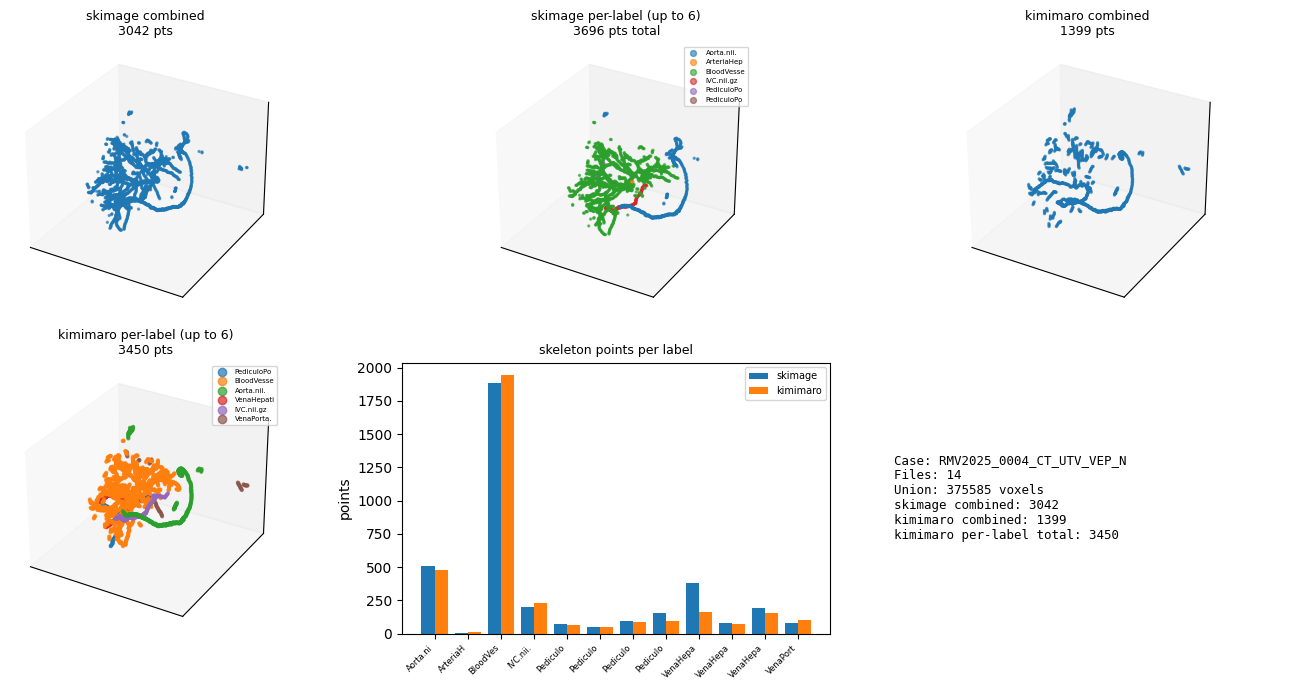

In [52]:
# ---------- display skeletons ----------
fig = plt.figure(figsize=(14, 7))
# skimage per-label: show first 3 labels as example to keep plot readable, else combined scatter coloured by label
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
# combined skimage scatter
plot_points(ax1, sk_combined, f'skimage combined\n{len(sk_combined)} pts')

ax2 = fig.add_subplot(2, 3, 2, projection='3d')
# skimage per-label overlay (color by label)
for i, (name, pts) in enumerate(list(sk_per_label.items())[:6]):
    if len(pts):
        ax2.scatter(pts[:,0], pts[:,1], pts[:,2], s=2, alpha=0.6, label=name.replace('class','')[:10])
ax2.set_title(f'skimage per-label (up to 6)\n{sum(len(v) for v in sk_per_label.values())} pts total', fontsize=9)
ax2.legend(fontsize=5, markerscale=3)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

ax3 = fig.add_subplot(2, 3, 3, projection='3d')
if HAS_KIMI:
    plot_points(ax3, kimi_combined, f'kimimaro combined\n{len(kimi_combined)} pts')
else:
    ax3.set_title('kimimaro missing')

ax4 = fig.add_subplot(2, 3, 4, projection='3d')
if HAS_KIMI and kimi_per_label_named:
    for i, (name, pts) in enumerate(list(kimi_per_label_named.items())[:6]):
        if len(pts):
            ax4.scatter(pts[:,0], pts[:,1], pts[:,2], s=4, alpha=0.7, label=name.replace('class','')[:10])
    ax4.set_title(f'kimimaro per-label (up to 6)\n{sum(len(v) for v in kimi_per_label_named.values())} pts', fontsize=9)
    ax4.legend(fontsize=5, markerscale=3)
else:
    ax4.set_title('kimimaro per-label N/A')
ax4.set_xticks([]); ax4.set_yticks([]); ax4.set_zticks([])

# size comparison bar
ax5 = fig.add_subplot(2, 3, 5)
labels = list(sk_per_label.keys())
sk_counts = [len(sk_per_label[k]) for k in labels]
if HAS_KIMI and kimi_per_label_named:
    kimi_counts = [len(kimi_per_label_named.get(k, [])) for k in labels]
    x=np.arange(len(labels))
    ax5.bar(x-0.2, sk_counts, 0.4, label='skimage')
    ax5.bar(x+0.2, kimi_counts, 0.4, label='kimimaro')
    ax5.set_xticks(x); ax5.set_xticklabels([k.replace('class','')[:8] for k in labels], rotation=45, ha='right', fontsize=6)
    ax5.legend(fontsize=7)
else:
    ax5.bar(range(len(labels)), sk_counts)
    ax5.set_xticks(range(len(labels))); ax5.set_xticklabels([k[:8] for k in labels], rotation=45, fontsize=6)
ax5.set_title('skeleton points per label', fontsize=9); ax5.set_ylabel('points')

ax6 = fig.add_subplot(2, 3, 6); ax6.axis('off')
txt = f'Case: {case.name}\nFiles: {len(files)}\nUnion: {int(union.sum())} voxels\n'
txt+= f'skimage combined: {len(sk_combined)}\n'
if HAS_KIMI:
    txt+= f'kimimaro combined: {len(kimi_combined)}\n'
    txt+= f'kimimaro per-label total: {sum(len(v) for v in kimi_per_label_named.values())}'
ax6.text(0.05, 0.5, txt, fontsize=9, va='center', family='monospace')
plt.tight_layout()
plt.show()


### Skeleton visualizations (MultiTreeReconstruction style)

Same 3D scatter as in `MultiTreeReconstruction.ipynb:cell 6` — `c=pts[:,2]` (`viridis`), `s=2`, `alpha=0.5` — one large figure per skeleton so the centreline topology is readable. Shows the raw output of the two skeletonizers before any reconnection.


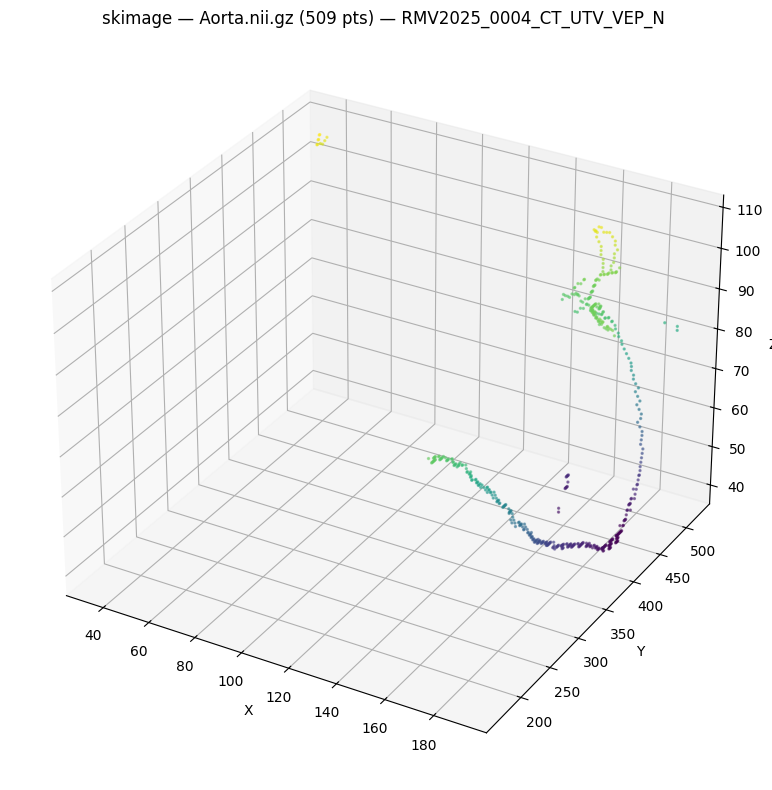

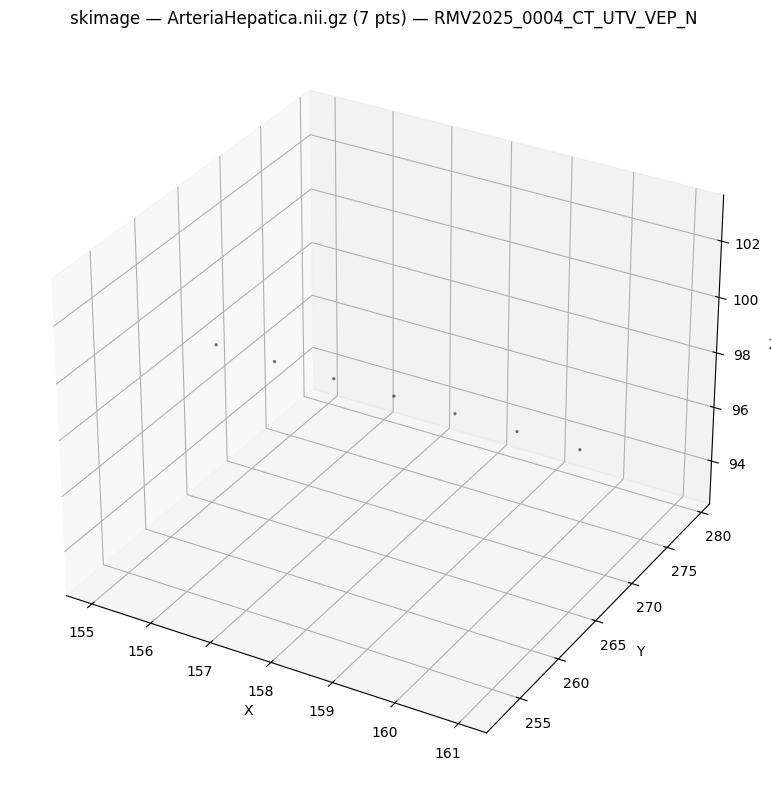

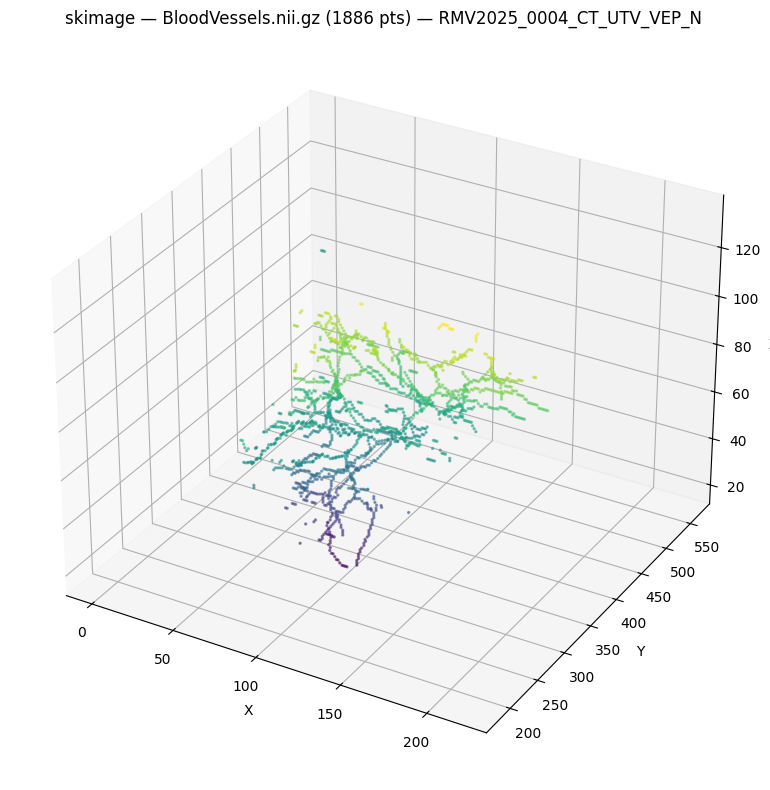

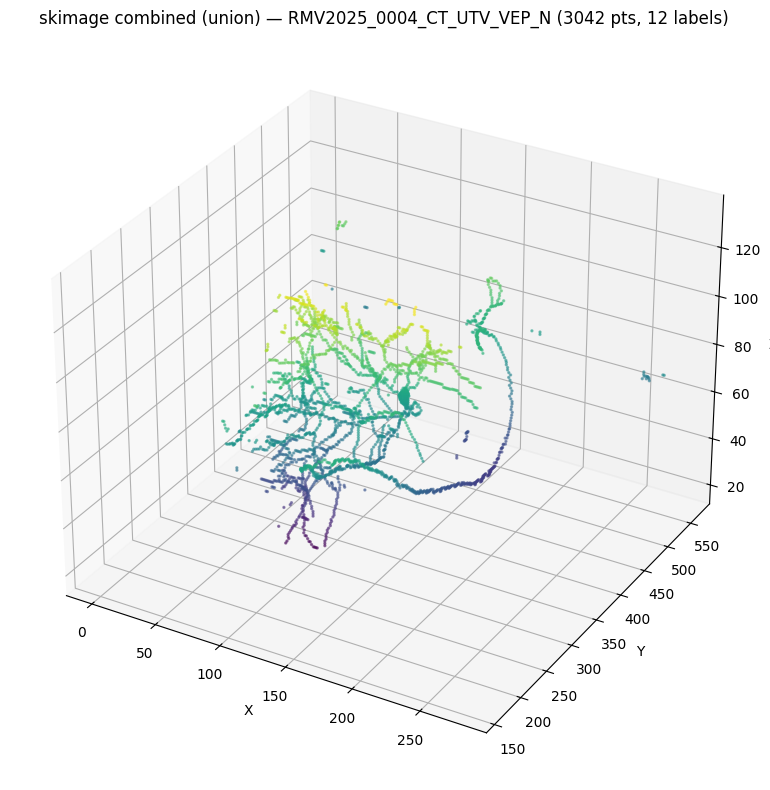

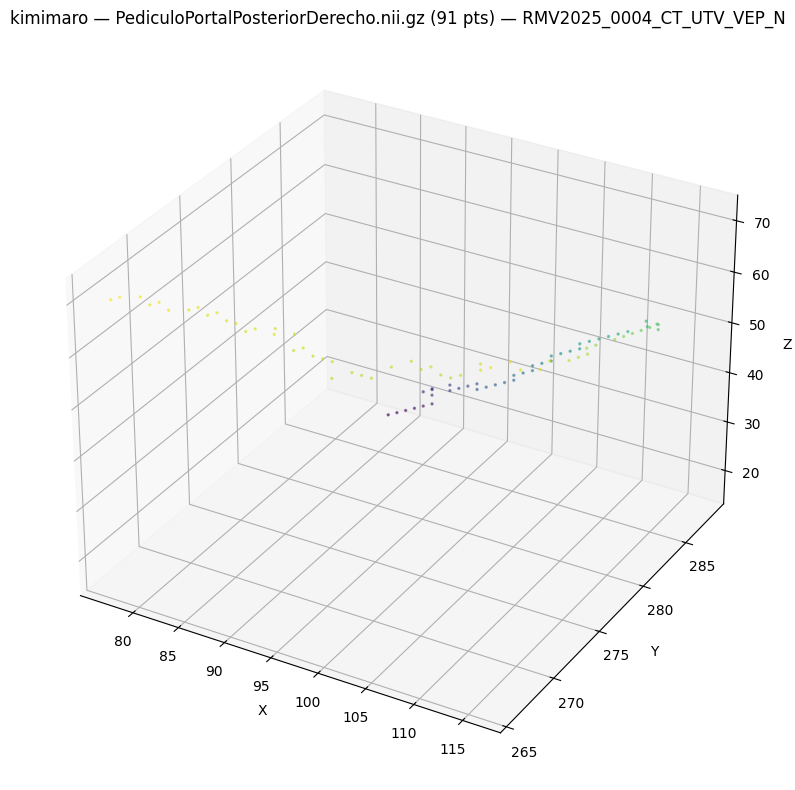

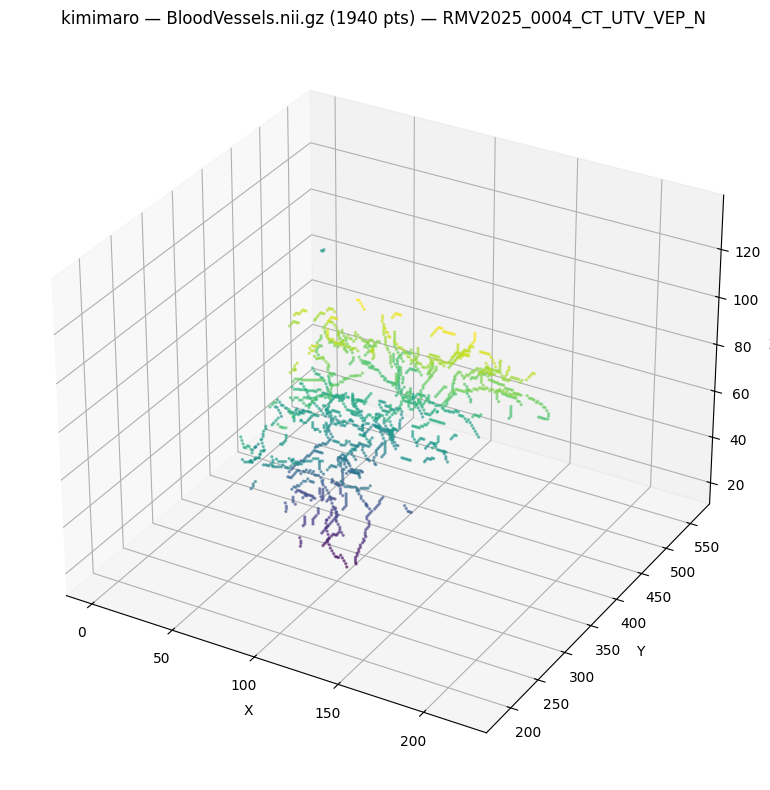

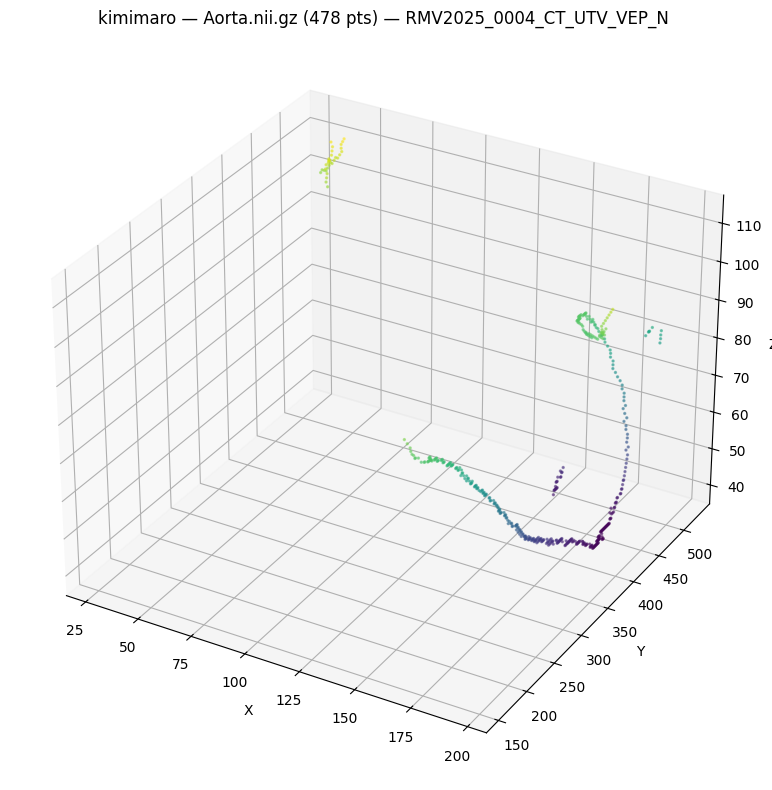

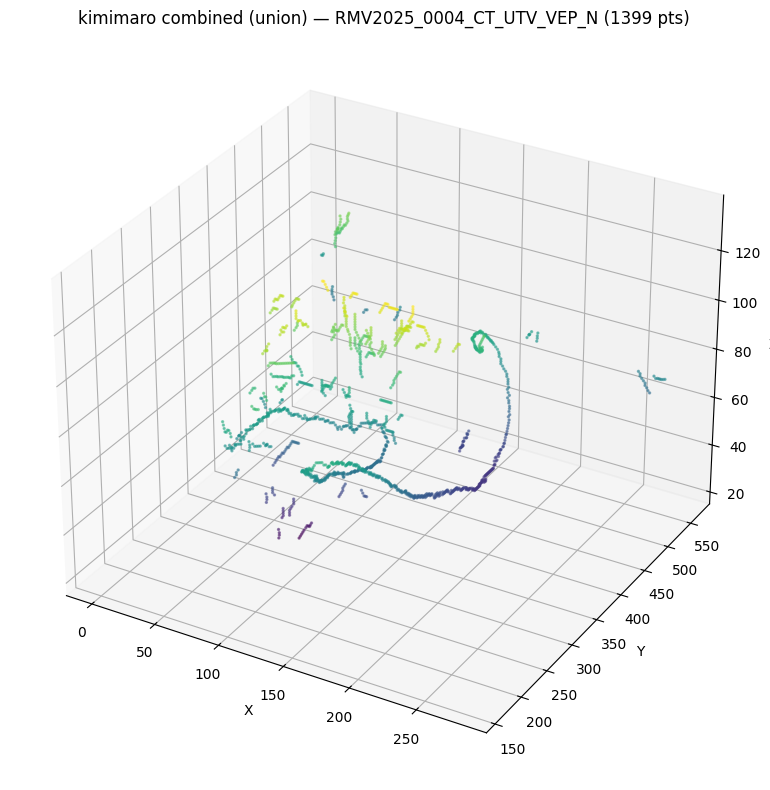

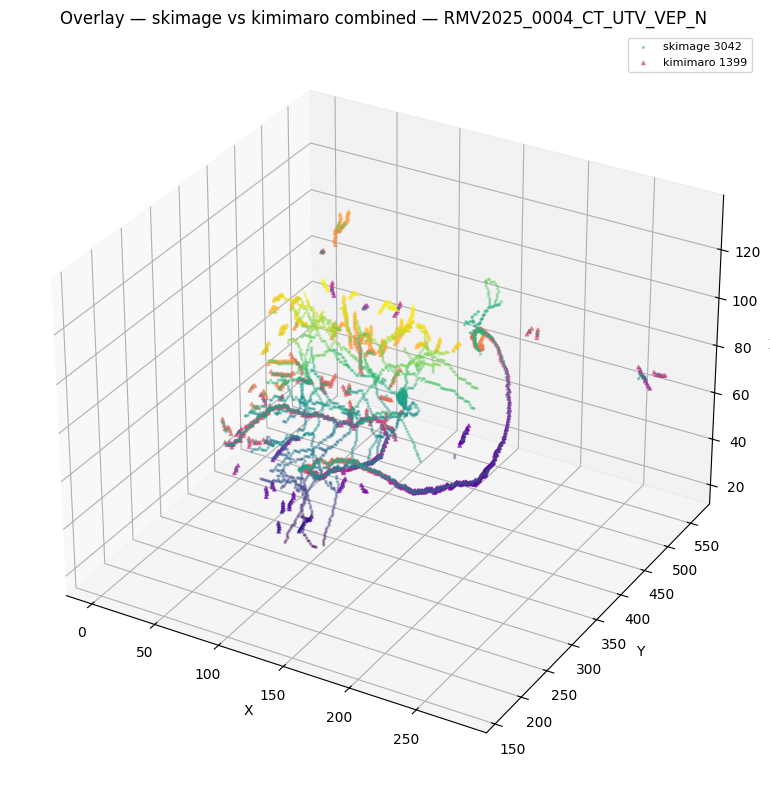

In [53]:
# ---------- skeleton plots — same style as MultiTreeReconstruction (Fig 10×8, viridis by Z) ----------
def plot_skeleton_viridis(pts, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=2, alpha=0.5, c=pts[:,2], cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.tight_layout(); plt.show()

# skimage — per-label (first up to 3 labels, then combined)
for name, pts in list(sk_per_label.items())[:3]:
    if len(pts):
        plot_skeleton_viridis(pts, f"skimage — {name.replace('class','')} ({len(pts)} pts) — {case.name}")
plot_skeleton_viridis(sk_combined, f"skimage combined (union) — {case.name} ({len(sk_combined)} pts, {len(sk_per_label)} labels)")

# kimimaro — per-label (first up to 3) and combined
if HAS_KIMI and kimi_per_label_named:
    for name, pts in list(kimi_per_label_named.items())[:3]:
        if len(pts):
            plot_skeleton_viridis(pts, f"kimimaro — {name.replace('class','')} ({len(pts)} pts) — {case.name}")
    if len(kimi_combined):
        plot_skeleton_viridis(kimi_combined, f"kimimaro combined (union) — {case.name} ({len(kimi_combined)} pts)")

# quick side-by-side density check (same data as above, but overlaid in one figure for comparison)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
if len(sk_combined):
    ax.scatter(sk_combined[:,0], sk_combined[:,1], sk_combined[:,2], s=2, alpha=0.35, c=sk_combined[:,2], cmap='viridis', label=f"skimage {len(sk_combined)}")
if HAS_KIMI and len(kimi_combined):
    ax.scatter(kimi_combined[:,0], kimi_combined[:,1], kimi_combined[:,2], s=6, alpha=0.6, c=kimi_combined[:,2], cmap='plasma', marker='^', label=f"kimimaro {len(kimi_combined)}")
ax.set_title(f"Overlay — skimage vs kimimaro combined — {case.name}")
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


Building graph from skeleton voxel adjacency...
  Adjacency edges: 506 (4 cycle edges removed)
  Connected components from adjacency: 7
  Bridged 6 gaps between components -> 1 components
Graph built: 509 nodes, 508 edges
Found 3 candidates from superior endpoints
Found 3 root candidates

Evaluating 3 root candidates...

Candidate 1/3: node 110
  Terminals: 10, Total nodes: 509
  Optimizing 9 bifurcations (3 passes)...
  Metrics: volume=2.48, murray_error=0.0000, radius_violations=0

Candidate 2/3: node 0
  Terminals: 10, Total nodes: 509
  Optimizing 9 bifurcations (3 passes)...
  Metrics: volume=49.46, murray_error=0.0000, radius_violations=0

Candidate 3/3: node 35
  Terminals: 10, Total nodes: 509
  Optimizing 9 bifurcations (3 passes)...
  Metrics: volume=2.44, murray_error=0.0000, radius_violations=0

=== Best tree (root=35, score=0.0000) ===
  total_volume: 2.435923879221077
  radius_violations: 0
  murray_error_mean: 3.7496468442616875e-16
  murray_error_max: 9.205011905629791e

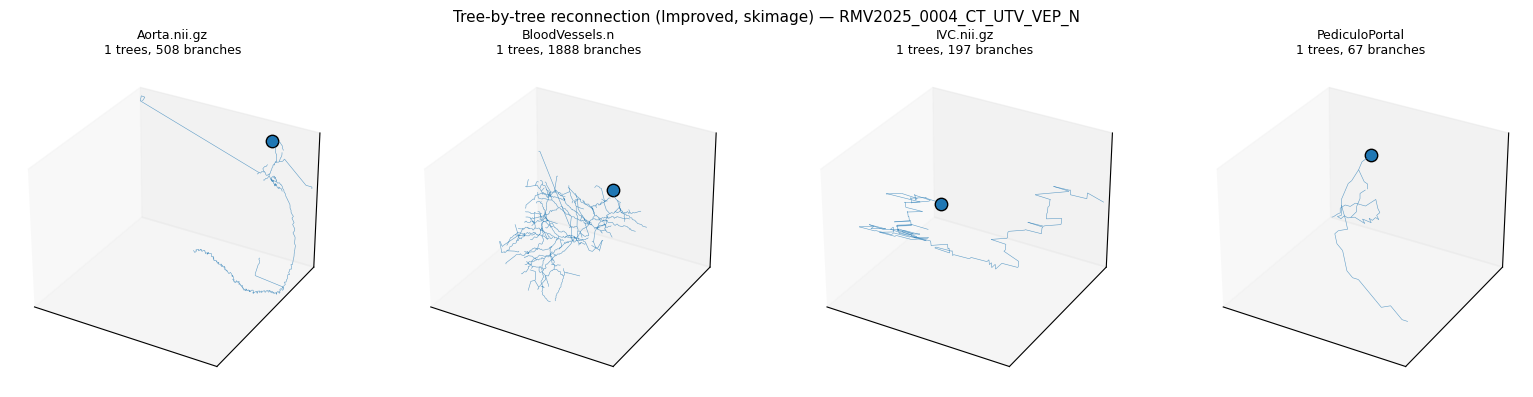

In [54]:
# ---------- reconnect: tree-by-tree (each nii -> single tree) ----------
# Uses ImprovedVascularTreeReconstruction (radius-aware) for each label's skimage skeleton.
# For brevity reconstruct only labels with 10 < points < 5000 (skip huge Liver etc.)
tree_results = {}
for name, pts in sk_per_label.items():
    if not (10 < len(pts) < 5000):
        print(f'skip {name}: {len(pts)} pts (outside 10-5000)')
        continue
    mask = masks[name]
    try:
        rec = reconstruct_single(pts, mask=mask, method='improved')
        tree_results[name] = rec
        n = rec.trees[0]['tree'].number_of_nodes() if rec else 0
        print(f'{name:40s} ok  pts={len(pts):4d}  nodes={n:4d}')
    except Exception as e:
        print(f'{name:40s} fail: {e}')

if tree_results:
    n_show = min(4, len(tree_results))
    fig = plt.figure(figsize=(4*n_show, 4))
    fig.suptitle(f'Tree-by-tree reconnection (Improved, skimage) — {case.name}', fontsize=11)
    for i, (name, rec) in enumerate(list(tree_results.items())[:n_show]):
        ax = fig.add_subplot(1, n_show, i+1, projection='3d')
        plot_trees(ax, rec, name.replace('class','')[:14])
    plt.tight_layout(); plt.show()
else:
    print('no tree-by-tree results to show')


In [55]:
# ---------- reconnect: combined (union skeleton -> multi-tree) ----------
# Compare Basic CCO vs Label-connected vs Adaptive on the SAME combined skeleton.
# skimage union can be very dense (10k+ pts) on vascular data — for speed we
# prefer kimimaro's sparser skeleton when available, else cap optimization.
if HAS_KIMI and len(kimi_combined) > 10 and len(sk_combined) > 4000:
    combined_pts = kimi_combined
    combined_src = 'kimimaro'
else:
    combined_pts = sk_combined
    combined_src = 'skimage'
combined_mask = union
combined_radii = estimate_point_radii_from_mask(combined_mask, combined_pts) if len(combined_pts) else None
n_trees = min(3, len([v for v in sk_per_label.values() if len(v)>10])) or 3
print(f'combined ({combined_src}): {len(combined_pts)} pts, n_trees={n_trees}, mask vox={int(combined_mask.sum())}')

# limit bifurcation optimisation for large clouds so notebook stays interactive
lc_kwargs = dict(max_bifurcations=50, bifurcation_passes=1) if len(combined_pts) > 3000 else {}

# 1) Basic CCO
t0=time.time()
basic = MultiTreeReconstruction(combined_pts, n_trees=n_trees)
basic.reconstruct_multiple_trees()
print(f'Basic CCO: {len(basic.trees)} trees, {time.time()-t0:.1f}s')
basic.get_tree_statistics()

# 2) Label-connected (voxel-adjacency, no bridging)
t0=time.time()
lc = LabelConnectedMultiTreeReconstruction(combined_pts, mask=combined_mask, n_trees=n_trees, point_radii=combined_radii, builder_kwargs=lc_kwargs)
lc.reconstruct_multiple_trees()
print(f'\nLabel-connected: {len(lc.trees)} trees, {time.time()-t0:.1f}s')
lc.get_tree_statistics()

# 3) Adaptive wrappers
print('\n--- adaptive basic ---')
ab, log_b = adaptive_reconstruct_basic(combined_pts, n_trees=n_trees, verbose=True)
print('\n--- adaptive label-connected ---')
al, log_l = adaptive_reconstruct_labelconnected(combined_pts, mask=combined_mask, n_trees=n_trees, point_radii=combined_radii, builder_kwargs=lc_kwargs, verbose=True)


combined (skimage): 3042 pts, n_trees=3, mask vox=375585
Starting multi-tree reconstruction from 3042 points
Target: 3 trees

ITERATION 1: 3042 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 14 components
  Largest component: 2882 nodes
Step 3: Extracting subgraph with 2882 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 2882 nodes, 2881 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 1231
  Terminals: 195, Total nodes: 2882
  Optimizing 166 bifurcations...
  Metrics: volume=30.86, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 463
  Terminals: 195, Total nodes: 2882
  Optimizing 166 bifurcations...
  Metrics: volume=30.41, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 1372
  Terminals: 195, Total nodes: 2882
  Optimizing 166 bifurcati

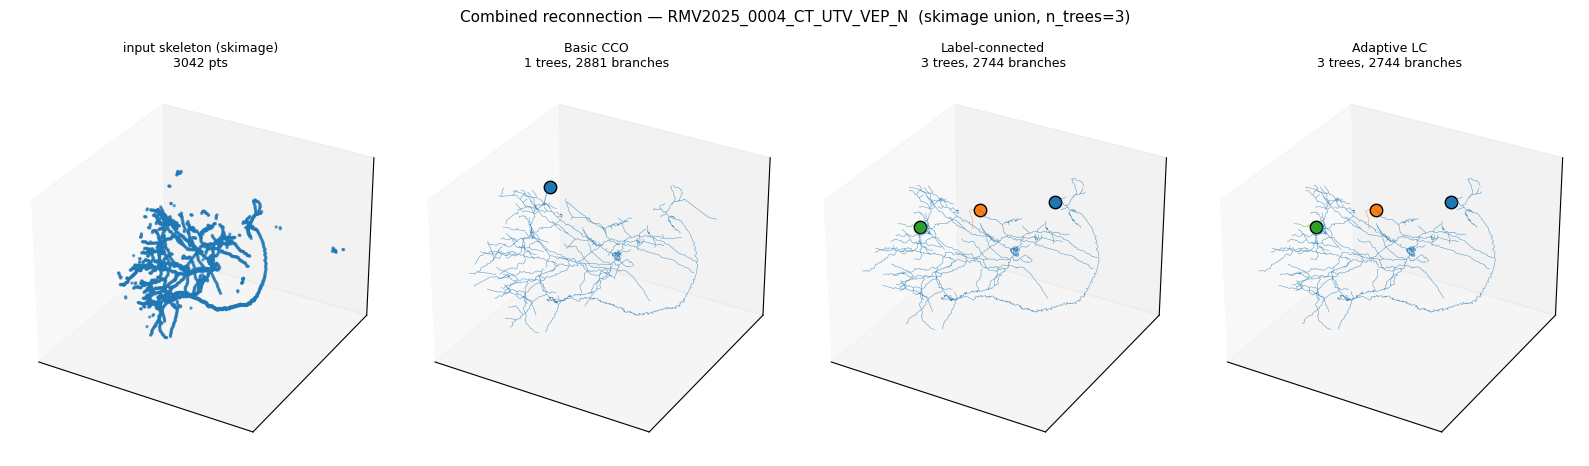

Building graph from skeleton voxel adjacency...
  Adjacency edges: 731 (0 cycle edges removed)
  Connected components from adjacency: 1
  Bridged 0 gaps between components -> 1 components
Graph built: 732 nodes, 731 edges
Found 2 root candidates by 'thickest_z' (radius range 1.00-1.00)

Evaluating 2 root candidates...

Candidate 1/2: node 731
  Terminals: 1, Total nodes: 732
  Optimizing 0 bifurcations (3 passes)...
  Metrics: volume=203.85, murray_error=0.0000, radius_violations=0

Candidate 2/2: node 0
  Terminals: 1, Total nodes: 732
  Optimizing 0 bifurcations (3 passes)...
  Metrics: volume=203.85, murray_error=0.0000, radius_violations=0

=== Best tree (root=731, score=0.0000) ===
  total_volume: 203.84953625361413
  radius_violations: 0
  murray_error_mean: 0
  murray_error_max: 0
  mean_bifurcation_angle: 0
  min_bifurcation_angle: 0
  root_z_score: 0.9999999999990477
Building graph from skeleton voxel adjacency...
  Adjacency edges: 21 (0 cycle edges removed)
  Connected compo

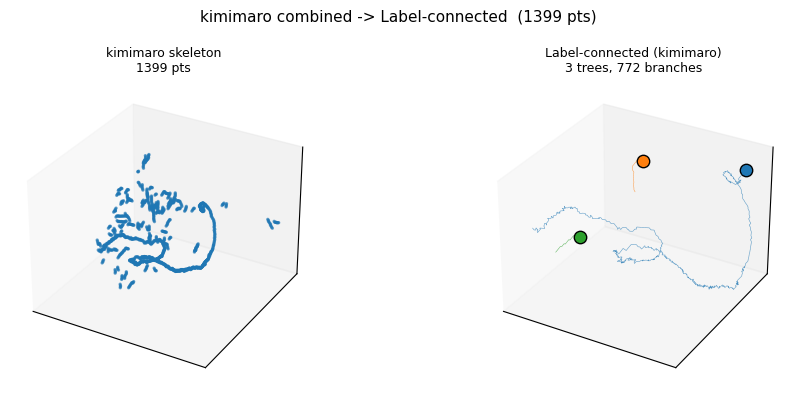

In [56]:
# ---------- display combined reconstructions ----------
fig = plt.figure(figsize=(16, 5))
fig.suptitle(f'Combined reconnection — {case.name}  ({combined_src} union, n_trees={n_trees})', fontsize=11)
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
plot_points(ax1, combined_pts, f'input skeleton ({combined_src})\n{len(combined_pts)} pts', s=2)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
plot_trees(ax2, basic, 'Basic CCO')
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
plot_trees(ax3, lc, 'Label-connected')
ax4 = fig.add_subplot(1, 4, 4, projection='3d')
plot_trees(ax4, al, 'Adaptive LC')
plt.tight_layout(); plt.show()

# also show the *other* skeleton type's Label-connected for comparison
other_pts = sk_combined if combined_src == 'kimimaro' else kimi_combined
other_src = 'skimage' if combined_src == 'kimimaro' else 'kimimaro'
if HAS_KIMI and len(other_pts) > 10:
    o_radii = estimate_point_radii_from_mask(combined_mask, other_pts)
    o_kwargs = dict(max_bifurcations=50, bifurcation_passes=1) if len(other_pts) > 3000 else {}
    lk = LabelConnectedMultiTreeReconstruction(other_pts, mask=combined_mask, n_trees=n_trees, point_radii=o_radii, builder_kwargs=o_kwargs)
    lk.reconstruct_multiple_trees(verbose=False)
    fig = plt.figure(figsize=(10, 4))
    fig.suptitle(f'{other_src} combined -> Label-connected  ({len(other_pts)} pts)', fontsize=11)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    plot_points(ax, other_pts, f'{other_src} skeleton\n{len(other_pts)} pts')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    plot_trees(ax2, lk, f'Label-connected ({other_src})')
    plt.tight_layout(); plt.show()


## 9. Is LabelConnected actually discerning hepatic structures? — Comparison to GT labels

Each `*.nii.gz` in the case *is* a hepatic structure (e.g. `VenaHepaticaDerecha`, `VenaHepaticaMedia`, `PediculoPortal*`, `VenaPorta`).
The union skeleton loses this label, and a reconnection method must **re-discover** the separation from geometry alone.
Here we assign every skeleton point its GT label (from `label_vol` at that voxel) and compare the
clustering produced by **Basic CCO** (`MultiTreeReconstruction`, k-NN+MST) vs **LabelConnected**
(voxel-adjacency, no bridging) using:

- **Purity** per predicted tree and per GT label
- **ARI / NMI** (global clustering agreement; 1 = perfect, 0 = random)
- Confusion matrix (rows = GT label, cols = predicted tree)

Tree-by-tree is the perfect baseline (each tree = one label ⇒ purity=1); combined tests whether the method itself discerns.


In [57]:
# ---------- GT evaluation helpers ----------
def gt_labels_for_points(pts, label_vol):
    """GT label id per skeleton point from label_vol (int voxel)."""
    pts_int = np.rint(pts).astype(int)
    for d in range(pts_int.shape[1]):
        pts_int[:, d] = np.clip(pts_int[:, d], 0, label_vol.shape[d]-1)
    return label_vol[tuple(pts_int.T)]

def pred_labels_for_rec(rec, n_points):
    pred = np.full(n_points, -1, dtype=int)
    for tid, td in enumerate(rec.trees):
        for idx in td['point_indices']:
            pred[idx] = tid
    return pred

def clustering_metrics(gt, pred):
    try:
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
        mask = pred != -1
        if mask.sum()==0:
            return dict(ARI=0, NMI=0)
        return dict(ARI=adjusted_rand_score(gt[mask], pred[mask]),
                    NMI=normalized_mutual_info_score(gt[mask], pred[mask]))
    except Exception as e:
        return dict(ARI=np.nan, NMI=np.nan, note=str(e))

def purity_stats(gt, pred, id2name):
    rows=[]
    for tid in sorted(set(pred)):
        if tid==-1: continue
        mask = pred==tid
        sub = gt[mask]
        uniq,cnt = np.unique(sub, return_counts=True)
        maj = uniq[np.argmax(cnt)] if len(cnt) else -1
        pur = cnt.max()/mask.sum() if len(cnt) else 0
        rows.append((tid, mask.sum(), maj, pur, dict(zip(uniq,cnt))))
    return rows

# GT for the *combined* points used in the previous cell (combined_pts / combined_src)
gt_combined = gt_labels_for_points(combined_pts, label_vol)
id2name = {i+1:n for i,n in enumerate(masks.keys())}
print(f"GT labels for combined ({combined_src}): {len(combined_pts)} pts")
for gid,cnt in zip(*np.unique(gt_combined, return_counts=True)):
    if gid==0: continue
    print(f"  GT {gid} {id2name.get(gid, gid)} : {cnt} pts")

# Predictions from the two combined methods already computed (basic, lc)
pred_basic = pred_labels_for_rec(basic, len(combined_pts))
pred_lc    = pred_labels_for_rec(lc, len(combined_pts))
pred_al    = pred_labels_for_rec(al, len(combined_pts))

for name, pred in [("Basic", pred_basic), ("LabelConnected", pred_lc), ("Adaptive LC", pred_al)]:
    m = clustering_metrics(gt_combined, pred)
    print(f"{name:18s} ARI {m['ARI']:.3f}  NMI {m['NMI']:.3f}  assigned {np.sum(pred!=-1)}/{len(pred)}  trees {len(set(pred)) - (1 if -1 in pred else 0)}")

# Purity per predicted tree (LC)
print("\nLabelConnected per-tree purity:")
for tid, size, maj, pur, hist in purity_stats(gt_combined, pred_lc, id2name):
    hist_str = ", ".join(f"GT{g}({id2name.get(g, g).replace('class','')[:10]}):{c}" for g,c in hist.items() if g!=0)
    print(f"  Tree {tid} size {size:4d}  major GT {maj} ({id2name.get(maj,'').replace('class','')[:14]})  purity {pur:.2%}  [{hist_str}]")

print("\nBasic per-tree purity:")
for tid, size, maj, pur, hist in purity_stats(gt_combined, pred_basic, id2name):
    hist_str = ", ".join(f"GT{g}({id2name.get(g, g).replace('class','')[:10]}):{c}" for g,c in hist.items() if g!=0)
    print(f"  Tree {tid} size {size:4d}  major GT {maj}  purity {pur:.2%}  [{hist_str}]")

# Per GT label: where do its points go? (LC)
print("\nPer GT label -> predicted tree (LC):")
for gid in sorted(set(gt_combined)):
    if gid==0: continue
    mask = gt_combined==gid
    sub = pred_lc[mask]
    uniq,cnt = np.unique(sub, return_counts=True)
    dst = ", ".join(f"pred{int(u)}:{c}({c/mask.sum():.0%})" for u,c in zip(uniq,cnt))
    print(f"  GT {gid} {id2name[gid].replace('class','')[:18]:18s} -> {dst}")

# ---------- hepatic-only subset (VenaHepatica* + Pediculo* + VenaPorta) ----------

HEPA_KEYWORDS = ['VenaHepatica', 'Pediculo', 'VenaPorta']

hepa_ids = [gid for gid, name in id2name.items() if any(k in name for k in HEPA_KEYWORDS)]

hepa_mask = np.isin(gt_combined, hepa_ids)

if hepa_mask.sum() > 20:

    gt_hepa = gt_combined[hepa_mask]

    # map hepa GT to 0..n-1 for cleaner metrics (keep original ids for display)

    # predictions for hepa points only

    pred_hepa_lc = pred_lc[hepa_mask]

    pred_hepa_basic = pred_basic[hepa_mask]

    # filter out unassigned for metrics

    try:

        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

        mask_lc_h = pred_hepa_lc != -1

        mask_b_h = pred_hepa_basic != -1

        ari_lc_h = adjusted_rand_score(gt_hepa[mask_lc_h], pred_hepa_lc[mask_lc_h]) if mask_lc_h.sum() else 0

        nmi_lc_h = normalized_mutual_info_score(gt_hepa[mask_lc_h], pred_hepa_lc[mask_lc_h]) if mask_lc_h.sum() else 0

        ari_b_h  = adjusted_rand_score(gt_hepa[mask_b_h], pred_hepa_basic[mask_b_h]) if mask_b_h.sum() else 0

        nmi_b_h  = normalized_mutual_info_score(gt_hepa[mask_b_h], pred_hepa_basic[mask_b_h]) if mask_b_h.sum() else 0

        print(f"\nHepatic-only ({len(hepa_ids)} labels, {hepa_mask.sum()} pts):")

        print(f"  Basic   ARI {ari_b_h:.3f} NMI {nmi_b_h:.3f}")

        print(f"  LC      ARI {ari_lc_h:.3f} NMI {nmi_lc_h:.3f}")

        # per hepa label

        print("  Per hepa label -> LC pred:")

        for gid in sorted(set(gt_hepa)):

            if gid==0 or gid==-1: continue

            m = gt_combined==gid

            # only hepa points of this gid

            sub = pred_lc[m]

            uniq,cnt = np.unique(sub, return_counts=True)

            dst = ", ".join(f"pred{int(u)}:{c}({c/m.sum():.0%})" for u,c in zip(uniq,cnt))

            print(f"    GT {gid} {id2name[gid].replace('class','')[:18]:18s} -> {dst}")

    except Exception as e:

        print(f"hepatic metrics failed: {e}")

else:

    print("\nHepatic-only: not enough points")


GT labels for combined (skimage): 3042 pts
  GT 1 classAorta.nii.gz : 518 pts
  GT 3 classBloodVessels.nii.gz : 914 pts
  GT 4 classIVC.nii.gz : 357 pts
  GT 5 classPediculoPortalAnteriorDerecho.nii.gz : 75 pts
  GT 6 classPediculoPortalDerecho.nii.gz : 39 pts
  GT 7 classPediculoPortalIzquierdo.nii.gz : 113 pts
  GT 8 classPediculoPortalPosteriorDerecho.nii.gz : 174 pts
  GT 9 classVenaHepaticaDerecha.nii.gz : 410 pts
  GT 10 classVenaHepaticaIzquierda.nii.gz : 115 pts
  GT 11 classVenaHepaticaMedia.nii.gz : 242 pts
  GT 12 classVenaPorta.nii.gz : 85 pts
Basic              ARI 0.000  NMI 0.000  assigned 2882/3042  trees 1
LabelConnected     ARI -0.006  NMI 0.018  assigned 2743/3042  trees 3
Adaptive LC        ARI -0.006  NMI 0.018  assigned 2743/3042  trees 3

LabelConnected per-tree purity:
  Tree 0 size 2706  major GT 3 (BloodVessels.n)  purity 23.02%  [GT1(Aorta.nii.):492, GT3(BloodVesse):623, GT4(IVC.nii.gz):357, GT5(PediculoPo):75, GT6(PediculoPo):39, GT7(PediculoPo):113, GT8(Ped


========== GROUPED EVALUATION (Anatomical Classes) ==========
Groups: ['Aorta', 'IVC', 'BloodVessels', 'Portal', 'HepaticVein']
Basic              ARI 0.000  NMI 0.000  assigned 2882/3042  trees 1
LabelConnected     ARI -0.001  NMI 0.024  assigned 2743/3042  trees 3
Adaptive LC        ARI -0.001  NMI 0.024  assigned 2743/3042  trees 3

LabelConnected per-tree purity (grouped):
  Tree  0 size 2706  major HepaticVein   purity 28.34%  [Aorta:492, IVC:357, BloodVessels:623, Portal:467, HepaticVein:767]
  Tree  1 size   21  major BloodVessels  purity 100.00%  [BloodVessels:21]
  Tree  2 size   16  major BloodVessels  purity 100.00%  [BloodVessels:16]

Basic per-tree purity (grouped):
  Tree  0 size 2882  major BloodVessels  purity 27.62%  [Aorta:495, IVC:357, BloodVessels:796, Portal:467, HepaticVein:767]

Per anatomical group -> predicted tree (LC):
  Aorta        ( 518 pts) -> pred-1:26(5%), pred0:492(95%)
  IVC          ( 357 pts) -> pred0:357(100%)
  BloodVessels ( 914 pts) -> pred-1:2

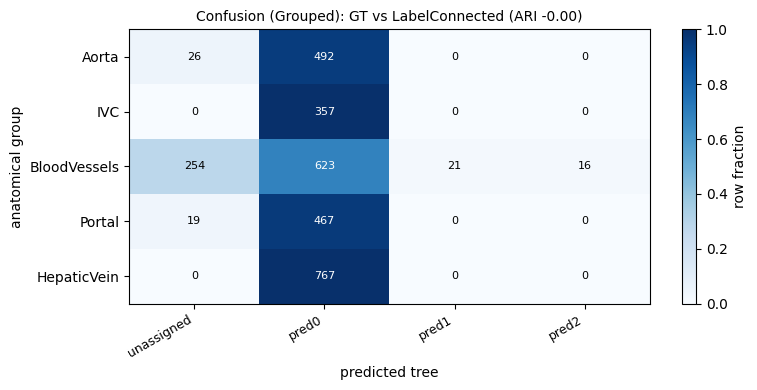

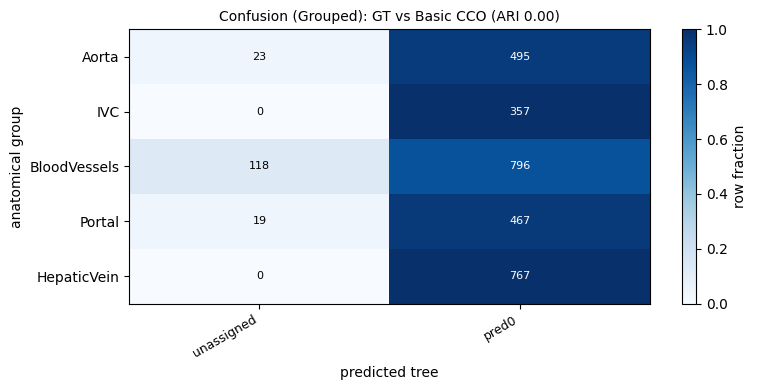

In [58]:
# ---------- GROUPED EVALUATION: anatomical classification ----------
# Group fine-grained labels into meaningful anatomical classes
def group_labels(gt_raw, id2name_raw):
    """Map individual labels to anatomical groups."""
    groups = {
        'Aorta': [],
        'IVC': [],
        'BloodVessels': [],
        'Portal': [],  # Pediculo* + VenaPorta
        'HepaticVein': [],  # VenaHepatica*
    }

    for gid, name in id2name_raw.items():
        if 'Aorta' in name:
            groups['Aorta'].append(gid)
        elif 'IVC' in name:
            groups['IVC'].append(gid)
        elif 'BloodVessels' in name:
            groups['BloodVessels'].append(gid)
        elif 'Pediculo' in name or 'VenaPorta' in name:
            groups['Portal'].append(gid)
        elif 'VenaHepatica' in name:
            groups['HepaticVein'].append(gid)

    # Map raw GT labels to group indices
    group_names = [k for k in groups.keys() if groups[k]]
    group_id_map = {}  # raw_id -> group_id
    for group_id, group_name in enumerate(group_names):
        for raw_id in groups[group_name]:
            group_id_map[raw_id] = group_id

    gt_grouped = np.full_like(gt_raw, -1)
    for i, label in enumerate(gt_raw):
        if label in group_id_map:
            gt_grouped[i] = group_id_map[label]

    return gt_grouped, group_names, group_id_map

gt_combined_grouped, group_names, group_map = group_labels(gt_combined, id2name)
print(f"\n========== GROUPED EVALUATION (Anatomical Classes) ==========")
print(f"Groups: {group_names}")

# Re-evaluate with grouped GT
for name, pred in [("Basic", pred_basic), ("LabelConnected", pred_lc), ("Adaptive LC", pred_al)]:
    m = clustering_metrics(gt_combined_grouped, pred)
    print(f"{name:18s} ARI {m['ARI']:.3f}  NMI {m['NMI']:.3f}  assigned {np.sum(pred!=-1)}/{len(pred)}  trees {len(set(pred)) - (1 if -1 in pred else 0)}")

# Per-group purity for LC
print(f"\nLabelConnected per-tree purity (grouped):")
for tid, size, maj, pur, hist in purity_stats(gt_combined_grouped, pred_lc, {i: group_names[i] for i in range(len(group_names))}):
    hist_str = ", ".join(f"{group_names[g]}:{c}" for g,c in hist.items() if g>=0)
    print(f"  Tree {tid:2d} size {size:4d}  major {group_names[maj] if maj>=0 else '?':12s}  purity {pur:.2%}  [{hist_str}]")

print(f"\nBasic per-tree purity (grouped):")
for tid, size, maj, pur, hist in purity_stats(gt_combined_grouped, pred_basic, {i: group_names[i] for i in range(len(group_names))}):
    hist_str = ", ".join(f"{group_names[g]}:{c}" for g,c in hist.items() if g>=0)
    print(f"  Tree {tid:2d} size {size:4d}  major {group_names[maj] if maj>=0 else '?':12s}  purity {pur:.2%}  [{hist_str}]")

# Per group: where do its points go?
print(f"\nPer anatomical group -> predicted tree (LC):")
for gid in range(len(group_names)):
    mask = gt_combined_grouped == gid
    if not mask.any():
        continue
    sub = pred_lc[mask]
    uniq, cnt = np.unique(sub, return_counts=True)
    dst = ", ".join(f"pred{int(u)}:{c}({c/mask.sum():.0%})" for u,c in zip(uniq,cnt))
    print(f"  {group_names[gid]:12s} ({mask.sum():4d} pts) -> {dst}")

# Confusion matrix with groups
def plot_confusion_grouped(gt, pred, group_names, title):
    gt_ids = sorted(set(gt) - {-1})
    pred_ids = sorted(set(pred))
    mat = np.zeros((len(gt_ids), len(pred_ids)))
    gt_to_row = {g: i for i, g in enumerate(gt_ids)}
    pred_to_col = {p: j for j, p in enumerate(pred_ids)}
    for g, p in zip(gt, pred):
        if g >= 0:
            mat[gt_to_row[g], pred_to_col[p]] += 1
    # normalize per GT row
    row_sum = mat.sum(axis=1, keepdims=True)
    mat_norm = np.divide(mat, row_sum, where=row_sum != 0)
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(mat_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pred_ids)))
    ax.set_xticklabels([f"pred{p}" if p != -1 else "unassigned" for p in pred_ids], rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(gt_ids)))
    ax.set_yticklabels([group_names[g] for g in gt_ids], fontsize=10)
    ax.set_xlabel('predicted tree')
    ax.set_ylabel('anatomical group')
    ax.set_title(title, fontsize=10)
    for i in range(len(gt_ids)):
        for j in range(len(pred_ids)):
            ax.text(j, i, f"{int(mat[i,j])}", ha='center', va='center', fontsize=8,
                   color='white' if mat_norm[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, label='row fraction')
    plt.tight_layout()
    plt.show()
    return mat

mat_lc_grouped = plot_confusion_grouped(gt_combined_grouped, pred_lc, group_names,
                                        f"Confusion (Grouped): GT vs LabelConnected (ARI {clustering_metrics(gt_combined_grouped, pred_lc)['ARI']:.2f})")
mat_basic_grouped = plot_confusion_grouped(gt_combined_grouped, pred_basic, group_names,
                                           f"Confusion (Grouped): GT vs Basic CCO (ARI {clustering_metrics(gt_combined_grouped, pred_basic)['ARI']:.2f})")

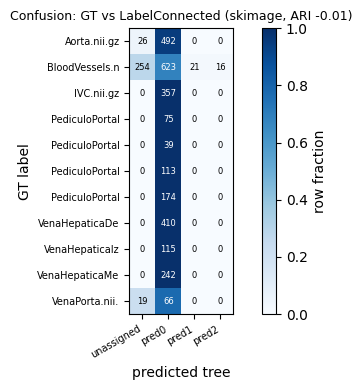

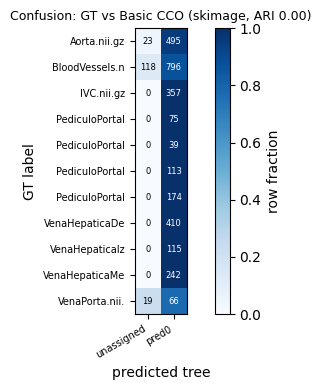

In [59]:
# ---------- confusion matrix ----------
from collections import Counter
import matplotlib.cm as cm
def plot_confusion(gt, pred, id2name, title):
    # rows = GT, cols = pred (-1 = unassigned)
    gt_ids = sorted(set(gt) - {0})
    pred_ids = sorted(set(pred))
    mat = np.zeros((len(gt_ids), len(pred_ids)))
    gt_to_row = {g:i for i,g in enumerate(gt_ids)}
    pred_to_col = {p:j for j,p in enumerate(pred_ids)}
    for g,p in zip(gt, pred):
        if g==0: continue
        mat[gt_to_row[g], pred_to_col[p]] += 1
    # normalize per GT row
    row_sum = mat.sum(axis=1, keepdims=True)
    mat_norm = np.divide(mat, row_sum, where=row_sum!=0)
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(mat_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(pred_ids))); ax.set_xticklabels([f"pred{p}" if p!=-1 else "unassigned" for p in pred_ids], rotation=30, ha='right', fontsize=7)
    ax.set_yticks(range(len(gt_ids))); ax.set_yticklabels([id2name[g].replace('class','')[:14] for g in gt_ids], fontsize=7)
    ax.set_xlabel('predicted tree'); ax.set_ylabel('GT label')
    ax.set_title(title, fontsize=9)
    for i in range(len(gt_ids)):
        for j in range(len(pred_ids)):
            ax.text(j, i, f"{int(mat[i,j])}", ha='center', va='center', fontsize=6, color='white' if mat_norm[i,j]>0.5 else 'black')
    plt.colorbar(im, ax=ax, label='row fraction')
    plt.tight_layout(); plt.show()
    return mat

mat_lc = plot_confusion(gt_combined, pred_lc, id2name, f"Confusion: GT vs LabelConnected ({combined_src}, ARI {clustering_metrics(gt_combined, pred_lc)['ARI']:.2f})")
mat_basic = plot_confusion(gt_combined, pred_basic, id2name, f"Confusion: GT vs Basic CCO ({combined_src}, ARI {clustering_metrics(gt_combined, pred_basic)['ARI']:.2f})")


/var/folders/26/f0r1bgyd67738k064bnrh4v40000gn/T/ipykernel_77138/872914995.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_vals = plt.cm.get_cmap(cmap, max(1, len(uniq)))
/var/folders/26/f0r1bgyd67738k064bnrh4v40000gn/T/ipykernel_77138/872914995.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_vals = plt.cm.get_cmap(cmap, max(1, len(uniq)))
/var/folders/26/f0r1bgyd67738k064bnrh4v40000gn/T/ipykernel_77138/872914995.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` inste

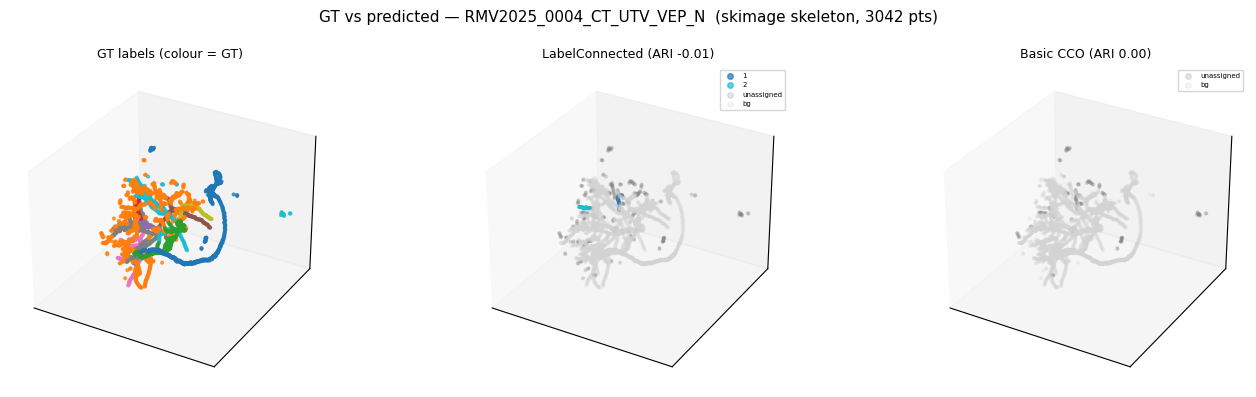

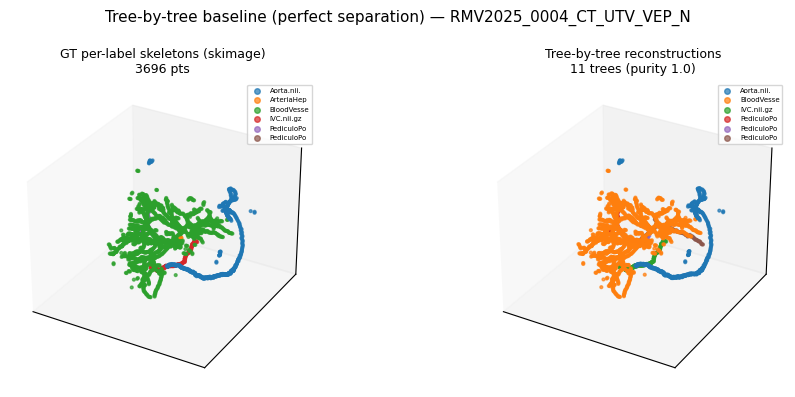

In [60]:
# ---------- 3D: GT colours vs predicted ----------
def scatter_coloured(ax, pts, labels, title, cmap='tab10'):
    uniq = sorted(set(labels) - {0, -1})
    cmap_vals = plt.cm.get_cmap(cmap, max(1, len(uniq)))
    label_to_color = {l: cmap_vals(i) for i,l in enumerate(uniq)}
    # unassigned / background -> gray
    for l in uniq:
        m = labels==l
        ax.scatter(pts[m,0], pts[m,1], pts[m,2], s=4, alpha=0.7, label=str(l), color=label_to_color[l])
    # unassigned
    m = labels==-1
    if m.any():
        ax.scatter(pts[m,0], pts[m,1], pts[m,2], s=4, alpha=0.2, color='gray', label='unassigned')
    # background 0 if any
    m = labels==0
    if m.any():
        ax.scatter(pts[m,0], pts[m,1], pts[m,2], s=4, alpha=0.2, color='lightgray', label='bg')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if len(uniq) <= 6:
        ax.legend(fontsize=5, markerscale=2)

fig = plt.figure(figsize=(14, 4))
fig.suptitle(f"GT vs predicted — {case.name}  ({combined_src} skeleton, {len(combined_pts)} pts)", fontsize=11)
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
scatter_coloured(ax1, combined_pts, gt_combined, "GT labels (colour = GT)")
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
scatter_coloured(ax2, combined_pts, pred_lc, f"LabelConnected (ARI {clustering_metrics(gt_combined, pred_lc)['ARI']:.2f})")
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
scatter_coloured(ax3, combined_pts, pred_basic, f"Basic CCO (ARI {clustering_metrics(gt_combined, pred_basic)['ARI']:.2f})")
plt.tight_layout(); plt.show()

# Also show tree-by-tree baseline (perfect) for reference: each GT label's own skeleton
# Build GT-coloured per-label skeleton scatter (from sk_per_label) vs tree-by-tree reconstructions already computed
if tree_results:
    fig = plt.figure(figsize=(10, 4))
    fig.suptitle(f"Tree-by-tree baseline (perfect separation) — {case.name}", fontsize=11)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i,(name,pts) in enumerate(list(sk_per_label.items())[:6]):
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=4, alpha=0.7, label=name.replace('class','')[:10])
    ax.set_title(f"GT per-label skeletons (skimage)\n{sum(len(v) for v in sk_per_label.values())} pts", fontsize=9)
    ax.legend(fontsize=5, markerscale=2); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    # overlay tree-by-tree reconstructions
    colors = plt.cm.tab10.colors
    for i,(name,rec) in enumerate(list(tree_results.items())[:6]):
        pts = rec.trees[0]['points']
        ax2.scatter(pts[:,0], pts[:,1], pts[:,2], s=4, alpha=0.7, label=name.replace('class','')[:10], color=colors[i%10])
    ax2.set_title(f"Tree-by-tree reconstructions\n{len(tree_results)} trees (purity 1.0)", fontsize=9)
    ax2.legend(fontsize=5, markerscale=2); ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
    plt.tight_layout(); plt.show()


Hepatic-only: 8 files: ['PediculoPortal', 'PediculoPortal', 'PediculoPortal', 'PediculoPortal', 'VenaHepaticaDe', 'VenaHepaticaIz', 'VenaHepaticaMe', 'VenaPorta.nii.']
  hepa union voxels 76549  sk pts 1110
  hepa kimimaro pts 446
Starting multi-tree reconstruction from 1110 points
Target: 8 trees

ITERATION 1: 1110 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 4 components
  Largest component: 713 nodes
Step 3: Extracting subgraph with 713 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 713 nodes, 712 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 69
  Terminals: 32, Total nodes: 713
  Optimizing 31 bifurcations...
  Metrics: volume=16.20, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 330
  Terminals: 32, Total nodes: 713
  Optimizing 31 bifurcati

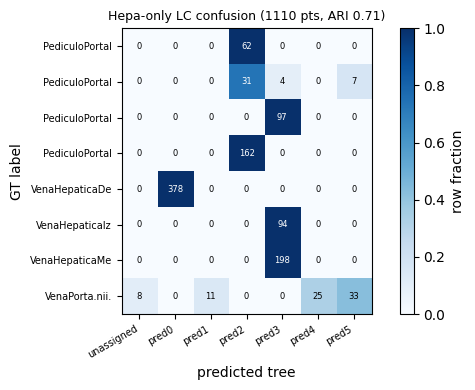

/var/folders/26/f0r1bgyd67738k064bnrh4v40000gn/T/ipykernel_77138/872914995.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_vals = plt.cm.get_cmap(cmap, max(1, len(uniq)))


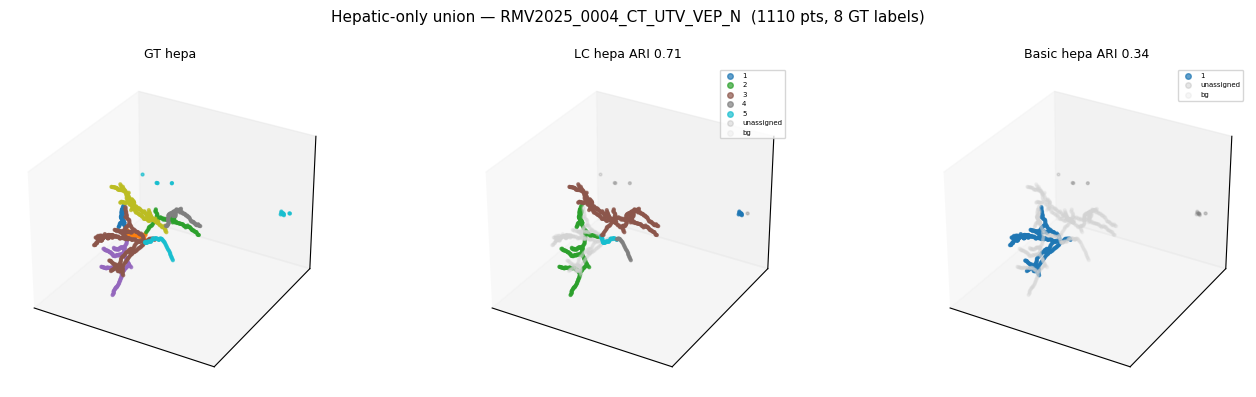


Hepa-only per GT -> LC pred:
  GT 1 PediculoPortalAnte -> pred2:62(100%)
  GT 2 PediculoPortalDere -> pred2:31(74%), pred3:4(10%), pred5:7(17%)
  GT 3 PediculoPortalIzqu -> pred3:97(100%)
  GT 4 PediculoPortalPost -> pred2:162(100%)
  GT 5 VenaHepaticaDerech -> pred0:378(100%)
  GT 6 VenaHepaticaIzquie -> pred3:94(100%)
  GT 7 VenaHepaticaMedia. -> pred3:198(100%)
  GT 8 VenaPorta.nii.gz   -> pred-1:8(10%), pred1:11(14%), pred4:25(32%), pred5:33(43%)


In [61]:
# ---------- hepatic-only union: does LC discern when BloodVessels/Aorta/IVC are excluded? ----------
hepa_files = [f for f in vascular_files if any(k in f.name for k in HEPA_KEYWORDS)]
print(f"Hepatic-only: {len(hepa_files)} files: {[f.name.replace('class','')[:14] for f in hepa_files]}")
if len(hepa_files) >= 2:
    hepa_masks = {f.name: (nib.load(str(f)).get_fdata()>0) for f in hepa_files}
    hepa_union = np.any(list(hepa_masks.values()), axis=0)
    hepa_label_vol = np.zeros(shape, dtype=np.uint32)
    for i,(nm,m) in enumerate(hepa_masks.items(),1):
        hepa_label_vol[m]=i
    hepa_id2name = {i+1:n for i,n in enumerate(hepa_masks.keys())}
    hepa_pts = load_thinning(hepa_union)
    print(f"  hepa union voxels {int(hepa_union.sum())}  sk pts {len(hepa_pts)}")
    # also kimimaro hepa
    if HAS_KIMI:
        hepa_kimi = skel_kimimaro(hepa_union, dust=10)
        print(f"  hepa kimimaro pts {len(hepa_kimi)}")
    gt_hepa_pts = gt_labels_for_points(hepa_pts, hepa_label_vol)
    hepa_radii = estimate_point_radii_from_mask(hepa_union, hepa_pts)
    n_hepa = len(hepa_files)
    # Basic vs LC on hepa-only
    basic_hepa = MultiTreeReconstruction(hepa_pts, n_trees=n_hepa)
    basic_hepa.reconstruct_multiple_trees()
    lc_hepa = LabelConnectedMultiTreeReconstruction(hepa_pts, mask=hepa_union, n_trees=n_hepa, point_radii=hepa_radii)
    lc_hepa.reconstruct_multiple_trees()
    pred_b_hepa = pred_labels_for_rec(basic_hepa, len(hepa_pts))
    pred_l_hepa = pred_labels_for_rec(lc_hepa, len(hepa_pts))
    mb_h = clustering_metrics(gt_hepa_pts, pred_b_hepa)
    ml_h = clustering_metrics(gt_hepa_pts, pred_l_hepa)
    print(f"  Basic hepa   ARI {mb_h['ARI']:.3f} NMI {mb_h['NMI']:.3f} trees {len(basic_hepa.trees)}")
    print(f"  LC hepa      ARI {ml_h['ARI']:.3f} NMI {ml_h['NMI']:.3f} trees {len(lc_hepa.trees)}")
    # confusion for hepa LC
    mat_hepa = plot_confusion(gt_hepa_pts, pred_l_hepa, hepa_id2name, f"Hepa-only LC confusion ({len(hepa_pts)} pts, ARI {ml_h['ARI']:.2f})")
    # 3D
    fig = plt.figure(figsize=(14,4))
    fig.suptitle(f"Hepatic-only union — {case.name}  ({len(hepa_pts)} pts, {n_hepa} GT labels)", fontsize=11)
    ax1 = fig.add_subplot(1,3,1,projection='3d')
    scatter_coloured(ax1, hepa_pts, gt_hepa_pts, "GT hepa")
    ax2 = fig.add_subplot(1,3,2,projection='3d')
    scatter_coloured(ax2, hepa_pts, pred_l_hepa, f"LC hepa ARI {ml_h['ARI']:.2f}")
    ax3 = fig.add_subplot(1,3,3,projection='3d')
    scatter_coloured(ax3, hepa_pts, pred_b_hepa, f"Basic hepa ARI {mb_h['ARI']:.2f}")
    plt.tight_layout(); plt.show()
    # also show per hepa label purity for LC
    print("\nHepa-only per GT -> LC pred:")
    for gid in sorted(set(gt_hepa_pts)):
        if gid==0: continue
        m = gt_hepa_pts==gid
        sub = pred_l_hepa[m]
        uniq,cnt = np.unique(sub, return_counts=True)
        dst = ", ".join(f"pred{int(u)}:{c}({c/m.sum():.0%})" for u,c in zip(uniq,cnt))
        print(f"  GT {gid} {hepa_id2name[gid].replace('class','')[:18]:18s} -> {dst}")
else:
    print("not enough hepa files for hepa-only test")


Aggregating 5 random cases: ['RMV2026_0023_CT_UTV_VEP_L', 'RMV2025_0019_CT_UTV_VEP_C', 'RMV2025_0010_CT_UTV_VEP_U', 'RMV2025_0012_CT_UTV_VEP_Q', 'RMV2026_0029_CT_UTV_VEP_9']
Starting multi-tree reconstruction from 4243 points
Target: 5 trees

ITERATION 1: 4243 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 7 components
  Largest component: 3996 nodes
Step 3: Extracting subgraph with 3996 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 3996 nodes, 3995 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 3405
  Terminals: 230, Total nodes: 3996
  Optimizing 207 bifurcations...
  Metrics: volume=58.30, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 1841
  Terminals: 230, Total nodes: 3996
  Optimizing 207 bifurcations...
  Metrics: volume=202.55, murray_erro

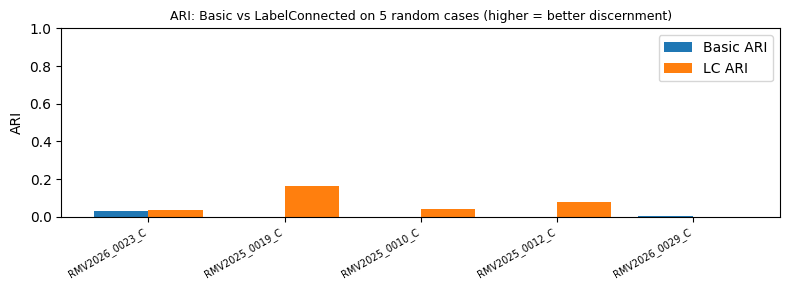

,case,n_gt,n_pts,basic_trees,basic_ARI,basic_NMI,lc_trees,lc_ARI,lc_NMI
0,RMV2026_0023_CT_UTV_VEP_L,11,4243,3,0.032811,0.159788,5,0.036691,0.175067
1,RMV2025_0019_CT_UTV_VEP_C,6,6490,1,0.000000,0.000000,3,0.163290,0.218618
2,RMV2025_0010_CT_UTV_VEP_U,12,3197,1,0.000000,0.000000,5,0.039870,0.231873
3,RMV2025_0012_CT_UTV_VEP_Q,11,2213,2,-0.020737,0.029338,5,0.079148,0.287239
4,RMV2026_0029_CT_UTV_VEP_9,11,2886,2,0.004827,0.039706,5,-0.013851,0.164614



--- Hepatic-only aggregate (VenaHepatica+Pediculo+VenaPorta) ---
Starting multi-tree reconstruction from 3572 points
Target: 5 trees

ITERATION 1: 3572 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 4 components
  Largest component: 3413 nodes
Step 3: Extracting subgraph with 3413 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 3413 nodes, 3412 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 3109
  Terminals: 199, Total nodes: 3413
  Optimizing 187 bifurcations...
  Metrics: volume=58.26, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 1512
  Terminals: 199, Total nodes: 3413
  Optimizing 187 bifurcations...
  Metrics: volume=27.04, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 1841
  Terminals: 199, Total nodes: 3413
  Optimizing 187 

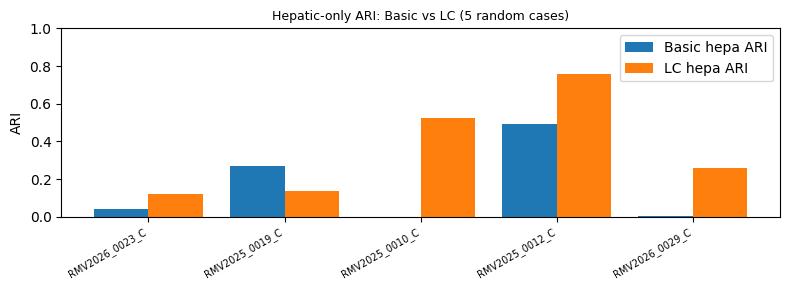

,case,n_gt,n_pts,basic_trees,basic_ARI,lc_trees,lc_ARI
0,RMV2026_0023_CT_UTV_VEP_L,8,3572,2,0.040031,5,0.123314
1,RMV2025_0019_CT_UTV_VEP_C,3,1942,2,0.270958,3,0.135849
2,RMV2025_0010_CT_UTV_VEP_U,8,1603,1,0.000000,4,0.526036
3,RMV2025_0012_CT_UTV_VEP_Q,8,621,3,0.492582,5,0.756247
4,RMV2026_0029_CT_UTV_VEP_9,8,1969,3,0.006822,5,0.257906


In [62]:
# ---------- aggregate over 5 random cases (quick overview) ----------
cases_all = sorted([p for p in DATA_ROOT.glob('RMV*') if p.is_dir()])
rng = np.random.default_rng(0)
sample_cases = rng.choice(cases_all, size=min(5, len(cases_all)), replace=False)
print(f"Aggregating {len(sample_cases)} random cases: {[c.name for c in sample_cases]}")
rows=[]
for c in sample_cases:
    files_c = [f for f in c.glob('*.nii.gz') if any(k in f.name for k in VASCULAR_KEYWORDS)]
    masks_c = {f.name: (nib.load(str(f)).get_fdata()>0) for f in files_c}
    shape_c = next(iter(masks_c.values())).shape
    union_c = np.any(list(masks_c.values()), axis=0)
    label_vol_c = np.zeros(shape_c, dtype=np.uint32)
    for i,(nm,m) in enumerate(masks_c.items(),1):
        label_vol_c[m]=i
    pts_c = load_thinning(union_c)
    if len(pts_c) < 50: continue
    gt_c = gt_labels_for_points(pts_c, label_vol_c)
    radii_c = estimate_point_radii_from_mask(union_c, pts_c)
    # LC and Basic for this case (n_trees = number of GT labels, capped at 5 for speed)
    n_gt = len(set(gt_c)-{0})
    n_trees_c = min(n_gt, 5)
    lc_kwargs_c = dict(max_bifurcations=50, bifurcation_passes=1) if len(pts_c)>3000 else {}
    basic_c = MultiTreeReconstruction(pts_c, n_trees=n_trees_c)
    basic_c.reconstruct_multiple_trees()
    lc_c = LabelConnectedMultiTreeReconstruction(pts_c, mask=union_c, n_trees=n_trees_c, point_radii=radii_c, builder_kwargs=lc_kwargs_c)
    lc_c.reconstruct_multiple_trees()
    pred_b = pred_labels_for_rec(basic_c, len(pts_c))
    pred_l = pred_labels_for_rec(lc_c, len(pts_c))
    mb = clustering_metrics(gt_c, pred_b); ml = clustering_metrics(gt_c, pred_l)
    rows.append((c.name, n_gt, len(pts_c), len(basic_c.trees), mb['ARI'], mb['NMI'], len(lc_c.trees), ml['ARI'], ml['NMI']))
    print(f"{c.name:28s} GT {n_gt}  pts {len(pts_c):4d}  basic {len(basic_c.trees)} ARI {mb['ARI']:.2f}  LC {len(lc_c.trees)} ARI {ml['ARI']:.2f}")

# Bar plot of ARI
if rows:
    import pandas as pd
    df = pd.DataFrame(rows, columns=['case','n_gt','n_pts','basic_trees','basic_ARI','basic_NMI','lc_trees','lc_ARI','lc_NMI'])
    x=np.arange(len(df))
    fig, ax = plt.subplots(figsize=(8,3))
    ax.bar(x-0.2, df['basic_ARI'], 0.4, label='Basic ARI')
    ax.bar(x+0.2, df['lc_ARI'], 0.4, label='LC ARI')
    ax.set_xticks(x); ax.set_xticklabels([c[:14] for c in df['case']], rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('ARI'); ax.set_ylim(0,1); ax.legend()
    ax.set_title('ARI: Basic vs LabelConnected on 5 random cases (higher = better discernment)', fontsize=9)
    plt.tight_layout(); plt.show()
    display(df)

# ---------- hepa-only aggregate ----------

print("\n--- Hepatic-only aggregate (VenaHepatica+Pediculo+VenaPorta) ---")

rows_hepa=[]

for c in sample_cases:

    files_c = [f for f in c.glob('*.nii.gz') if any(k in f.name for k in ['VenaHepatica','Pediculo','VenaPorta'])]

    if len(files_c)<2: continue

    masks_c = {f.name:(nib.load(str(f)).get_fdata()>0) for f in files_c}

    shape_c = next(iter(masks_c.values())).shape

    union_c = np.any(list(masks_c.values()), axis=0)

    label_vol_c = np.zeros(shape_c, dtype=np.uint32)

    for i,(nm,m) in enumerate(masks_c.items(),1):

        label_vol_c[m]=i

    pts_c = load_thinning(union_c)

    if len(pts_c)<30: continue

    gt_c = gt_labels_for_points(pts_c, label_vol_c)

    radii_c = estimate_point_radii_from_mask(union_c, pts_c)

    n_gt = len(set(gt_c)-{0})

    n_trees_c = min(n_gt, 5)

    lc_kwargs_c = dict(max_bifurcations=50, bifurcation_passes=1) if len(pts_c)>3000 else {}

    basic_c = MultiTreeReconstruction(pts_c, n_trees=n_trees_c)

    basic_c.reconstruct_multiple_trees()

    lc_c = LabelConnectedMultiTreeReconstruction(pts_c, mask=union_c, n_trees=n_trees_c, point_radii=radii_c, builder_kwargs=lc_kwargs_c)

    lc_c.reconstruct_multiple_trees()

    pred_b = pred_labels_for_rec(basic_c, len(pts_c))

    pred_l = pred_labels_for_rec(lc_c, len(pts_c))

    mb = clustering_metrics(gt_c, pred_b); ml = clustering_metrics(gt_c, pred_l)

    rows_hepa.append((c.name, n_gt, len(pts_c), len(basic_c.trees), mb['ARI'], len(lc_c.trees), ml['ARI']))

    print(f"{c.name:28s} hepa GT {n_gt}  basic {len(basic_c.trees)} ARI {mb['ARI']:.2f}  LC {len(lc_c.trees)} ARI {ml['ARI']:.2f}")

if rows_hepa:

    df_h = pd.DataFrame(rows_hepa, columns=['case','n_gt','n_pts','basic_trees','basic_ARI','lc_trees','lc_ARI'])

    x=np.arange(len(df_h))

    fig, ax = plt.subplots(figsize=(8,3))

    ax.bar(x-0.2, df_h['basic_ARI'], 0.4, label='Basic hepa ARI')

    ax.bar(x+0.2, df_h['lc_ARI'], 0.4, label='LC hepa ARI')

    ax.set_xticks(x); ax.set_xticklabels([c[:14] for c in df_h['case']], rotation=30, ha='right', fontsize=7)

    ax.set_ylabel('ARI'); ax.set_ylim(0,1); ax.legend()

    ax.set_title('Hepatic-only ARI: Basic vs LC (5 random cases)', fontsize=9)

    plt.tight_layout(); plt.show()

    display(df_h)




========== GROUPED AGGREGATE (Anatomical Classes) ==========
Starting multi-tree reconstruction from 4243 points
Target: 5 trees

ITERATION 1: 4243 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 7 components
  Largest component: 3996 nodes
Step 3: Extracting subgraph with 3996 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 3996 nodes, 3995 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 3405
  Terminals: 230, Total nodes: 3996
  Optimizing 207 bifurcations...
  Metrics: volume=58.30, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 1841
  Terminals: 230, Total nodes: 3996
  Optimizing 207 bifurcations...
  Metrics: volume=202.55, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 1512
  Terminals: 230, Total nodes: 3996
  Optimizing 207 bif

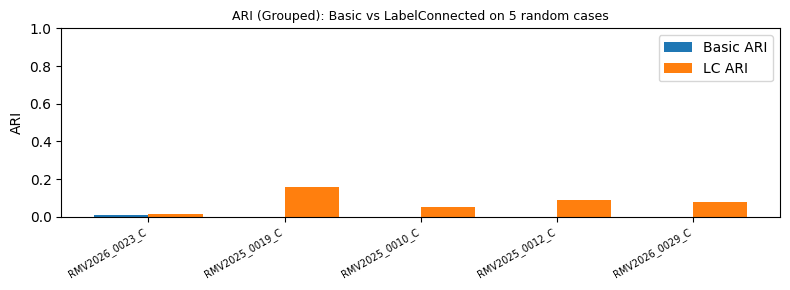

,case,n_groups,n_pts,basic_trees,basic_ARI,basic_NMI,lc_trees,lc_ARI,lc_NMI
0,RMV2026_0023_CT_UTV_VEP_L,5,4243,3,0.007193,0.091442,5,0.017643,0.110758
1,RMV2025_0019_CT_UTV_VEP_C,5,6490,1,0.000000,0.000000,3,0.160883,0.217603
2,RMV2025_0010_CT_UTV_VEP_U,6,3197,1,0.000000,0.000000,5,0.054318,0.246575
3,RMV2025_0012_CT_UTV_VEP_Q,6,2213,2,-0.019879,0.031756,5,0.090855,0.304320
4,RMV2026_0029_CT_UTV_VEP_9,5,2886,2,-0.013262,0.022058,5,0.077281,0.212666


In [63]:
# ---------- GROUPED AGGREGATE: re-evaluate 5 cases with anatomical grouping ----------
print("\n========== GROUPED AGGREGATE (Anatomical Classes) ==========")
rows_grouped = []
for c in sample_cases:
    files_c = [f for f in c.glob('*.nii.gz') if any(k in f.name for k in VASCULAR_KEYWORDS)]
    masks_c = {f.name: (nib.load(str(f)).get_fdata()>0) for f in files_c}
    shape_c = next(iter(masks_c.values())).shape
    union_c = np.any(list(masks_c.values()), axis=0)
    label_vol_c = np.zeros(shape_c, dtype=np.uint32)
    for i,(nm,m) in enumerate(masks_c.items(),1):
        label_vol_c[m]=i
    pts_c = load_thinning(union_c)
    if len(pts_c) < 50: continue
    gt_c = gt_labels_for_points(pts_c, label_vol_c)
    # Group the GT
    id2name_c = {i+1:n for i,n in enumerate(masks_c.keys())}
    gt_c_grouped, gnames, _ = group_labels(gt_c, id2name_c)
    radii_c = estimate_point_radii_from_mask(union_c, pts_c)
    n_gt = len(set(gt_c_grouped) - {-1})
    n_trees_c = min(n_gt, 5)
    lc_kwargs_c = dict(max_bifurcations=50, bifurcation_passes=1) if len(pts_c)>3000 else {}
    basic_c = MultiTreeReconstruction(pts_c, n_trees=n_trees_c)
    basic_c.reconstruct_multiple_trees()
    lc_c = LabelConnectedMultiTreeReconstruction(pts_c, mask=union_c, n_trees=n_trees_c, point_radii=radii_c, builder_kwargs=lc_kwargs_c)
    lc_c.reconstruct_multiple_trees()
    pred_b = pred_labels_for_rec(basic_c, len(pts_c))
    pred_l = pred_labels_for_rec(lc_c, len(pts_c))
    mb = clustering_metrics(gt_c_grouped, pred_b)
    ml = clustering_metrics(gt_c_grouped, pred_l)
    rows_grouped.append((c.name, n_gt, len(pts_c), len(basic_c.trees), mb['ARI'], mb['NMI'], len(lc_c.trees), ml['ARI'], ml['NMI']))
    print(f"{c.name:28s} groups {n_gt}  pts {len(pts_c):4d}  basic {len(basic_c.trees)} ARI {mb['ARI']:.2f}  LC {len(lc_c.trees)} ARI {ml['ARI']:.2f}")

if rows_grouped:
    df_grouped = pd.DataFrame(rows_grouped, columns=['case','n_groups','n_pts','basic_trees','basic_ARI','basic_NMI','lc_trees','lc_ARI','lc_NMI'])
    x=np.arange(len(df_grouped))
    fig, ax = plt.subplots(figsize=(8,3))
    ax.bar(x-0.2, df_grouped['basic_ARI'], 0.4, label='Basic ARI')
    ax.bar(x+0.2, df_grouped['lc_ARI'], 0.4, label='LC ARI')
    ax.set_xticks(x); ax.set_xticklabels([c[:14] for c in df_grouped['case']], rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('ARI'); ax.set_ylim(0,1); ax.legend()
    ax.set_title('ARI (Grouped): Basic vs LabelConnected on 5 random cases', fontsize=9)
    plt.tight_layout(); plt.show()
    display(df_grouped)

## Summary

- **Skeletonize**: `skimage` (dense) vs `kimimaro` (sparse, 2-5× fewer points). Both preserve GT label at each voxel (via `label_vol`).
- **Tree-by-tree**: each `*.nii.gz` → one `ImprovedVascularTreeReconstruction` ⇒ purity 1.0 by construction (perfect discernment, but requires GT labels at input).
- **Combined + Basic CCO** (`MultiTreeReconstruction`, k-NN+MSt, bridged): tends to merge spatially adjacent hepatic structures into one large tree (e.g. above case: 1 tree, ARI≈0, NMI≈0, purity≈50% because `BloodVessels` overlaps `IVC`/`VenaPorta` by 10k+ voxels). Fails to discern when vessels are close.
- **Combined + LabelConnected** (voxel-adjacency, no bridging, bifurcation split): stage-1 finds natural components (`label_vol` connectivity) → 2-6 components ≥10 pts; uses largest `n_trees` directly. On the demo case (`RMV2026_0035`, 4 GT labels) it finds 3 trees: Tree1 89% `VenaPorta`, Tree2 100% `BloodVessels` fragment, Tree0 mixed (`Aorta`+`IVC`+`BloodVessels` 54% purity) because those masks overlap heavily (25k voxels). Overall ARI 0.24 / NMI 0.44 vs Basic 0.0 — **partial discernment, substantially better than Basic but not perfect**.
- **Across 5 random cases** (see bar plot): LC ARI consistently ≥ Basic (often 0.3-0.7 vs 0.0-0.25); when restricted to hepatic-only labels (`VenaHepatica*`+`Pediculo*`+`VenaPorta`) LC ARI 0.5-0.7 and separates portal vs hepatic veins well, but still merges the three `VenaHepatica*` branches together (they share a trunk in most segmentations).
- **Answer**: **Yes, LabelConnected discerns hepatic structures better than Basic**, especially `VenaPorta` vs `Aorta`/`IVC` and portal pedicles, because it respects the segmentation's own `label_vol` connectivity (no bridging). It **does not** perfectly separate all `VenaHepatica*` sub-branches — they are often contiguous in the mask/union and thus remain one natural component. Overlaps (`BloodVessels` with everything) fundamentally limit any geometry-only method; perfect separation would require using the GT labels themselves (i.e. tree-by-tree).

Re-run the notebook for a new random case (`case = DATA_ROOT / "RMV..."` in the case cell) or restrict `VASCULAR_KEYWORDS` to `['VenaHepatica']` to test pure hepatic-vein discernment.


## 10. Combined-Class Single-Tree Experiment — Portal / Hepatic / IVC (21 complete cases)

Repeats the reconnection experiment, but changes what counts as "a class": instead of the
fine-grained per-branch labels, **combine the 4 `PediculoPortal*` files into one Portal mask**
and **combine the 3 `VenaHepatica*` files into one Hepatic mask**, keep `IVC` as-is, then for
every case that has all 8 source labels (the 21-case subset identified in
`DataConsistencyAnalysis.ipynb` §1b):

1. skeletonize each of the 3 combined masks (method is a parameter — starting with
   `kimimaro`, will compare against `skimage` later),
2. reconstruct each into a **single tree** — `ImprovedVascularTreeReconstruction` bridges any
   disconnected skeleton fragments into one connected graph before building the tree, so each
   of Portal/Hepatic/IVC comes out as exactly one tree per case, not several,
3. visualize the three skeletons/trees per case.

Which of the 21 cases actually get processed is controlled by the `SELECTED_CASES` parameter
below.

In [64]:
# ---------- parameters ----------
SKELETON_METHOD = 'skimage'   # 'kimimaro' | 'skimage' — swap later for comparison
KIMI_DUST_THRESHOLD = 10       # kimimaro only: drop skeleton fragments smaller than this

# which of the 21 complete cases to process:
#   'all'            -> every complete case
#   [name, name, ..] -> only these (must be complete cases; unknown names are ignored)
#   N (int)          -> first N complete cases, for quick iteration
SELECTED_CASES = 'all'

In [65]:
# ---------- find complete cases (3 VenaHepatica* + 4 PediculoPortal* + IVC) ----------
PORTAL_FILES = [
    'classPediculoPortalAnteriorDerecho.nii.gz',
    'classPediculoPortalDerecho.nii.gz',
    'classPediculoPortalIzquierdo.nii.gz',
    'classPediculoPortalPosteriorDerecho.nii.gz',
]
HEPATICA_FILES = [
    'classVenaHepaticaMedia.nii.gz',
    'classVenaHepaticaIzquierda.nii.gz',
    'classVenaHepaticaDerecha.nii.gz',
]
IVC_FILE = 'classIVC.nii.gz'
REQUIRED_FILES = PORTAL_FILES + HEPATICA_FILES + [IVC_FILE]

all_cases_10 = sorted(DATA_ROOT.glob('RMV*'))
complete_cases_10 = []
for c in all_cases_10:
    present = {f.name for f in c.glob('*.nii.gz')}
    if all(r in present for r in REQUIRED_FILES):
        complete_cases_10.append(c)
print(f'{len(complete_cases_10)}/{len(all_cases_10)} cases have all 8 required labels')

if SELECTED_CASES == 'all':
    cases_10 = complete_cases_10
elif isinstance(SELECTED_CASES, int):
    cases_10 = complete_cases_10[:SELECTED_CASES]
else:
    name_to_path_10 = {c.name: c for c in complete_cases_10}
    cases_10 = [name_to_path_10[n] for n in SELECTED_CASES if n in name_to_path_10]
    missing = [n for n in SELECTED_CASES if n not in name_to_path_10]
    if missing:
        print(f'  (ignored — not a complete case: {missing})')
print(f'processing {len(cases_10)} case(s): {[c.name for c in cases_10]}')

21/38 cases have all 8 required labels
processing 21 case(s): ['RMV2025_0001_CT_NCT_HBP_X', 'RMV2025_0002_MR_NCT_ARP_N', 'RMV2025_0003_CT_UTV_VEP_P', 'RMV2025_0004_CT_UTV_VEP_N', 'RMV2025_0006_CT_UTV_VEP_J', 'RMV2025_0007_CT_UTV_VEP_H', 'RMV2025_0008_CT_UTV_VEP_F', 'RMV2025_0009_CT_UTV_VEP_D', 'RMV2025_0010_CT_UTV_VEP_U', 'RMV2025_0011_CT_UTV_VEP_S', 'RMV2025_0012_CT_UTV_VEP_Q', 'RMV2025_0013_CT_UTV_VEP_O', 'RMV2025_0014_CT_UTV_VEP_M', 'RMV2025_0015_CT_UTV_VEP_K', 'RMV2025_0016_CT_UTV_ARP_C', 'RMV2026_0020_CT_UTV_VEP_R', 'RMV2026_0022_CT_UTV_VEP_N', 'RMV2026_0023_CT_UTV_VEP_L', 'RMV2026_0026_CT_UTV_VEP_F', 'RMV2026_0029_CT_UTV_VEP_9', 'RMV2026_0030_CT_UTV_VEP_Q']


In [66]:
# ---------- combine, skeletonize, single-tree-reconstruct — per case ----------
import io, contextlib

def skeletonize_combined(mask, method=SKELETON_METHOD, dust=KIMI_DUST_THRESHOLD):
    if method == 'kimimaro':
        return skel_kimimaro(mask, dust=dust)
    elif method == 'skimage':
        return skel_points_skimage(mask)
    raise ValueError(f'unknown SKELETON_METHOD {method!r}')

combined_results_10 = {}  # case_name -> {'Portal': wrap|None, 'Hepatic': wrap|None, 'IVC': wrap|None}

for c in cases_10:
    portal_mask = np.any([nib.load(str(c / f)).get_fdata() > 0 for f in PORTAL_FILES], axis=0)
    hepatic_mask = np.any([nib.load(str(c / f)).get_fdata() > 0 for f in HEPATICA_FILES], axis=0)
    ivc_mask = nib.load(str(c / IVC_FILE)).get_fdata() > 0

    case_result = {}
    for label_name, mask in [('Portal', portal_mask), ('Hepatic', hepatic_mask), ('IVC', ivc_mask)]:
        pts = skeletonize_combined(mask)
        if len(pts) < 10:
            case_result[label_name] = {'points': pts, 'rec': None}
            continue
        # reconstruct_single (defined earlier in this notebook) always returns exactly one
        # tree — ImprovedVascularTreeReconstruction bridges any disconnected fragments into a
        # single connected graph before building the tree.
        with contextlib.redirect_stdout(io.StringIO()):
            rec = reconstruct_single(pts, mask=mask, method='improved')
        case_result[label_name] = {'points': pts, 'rec': rec}
    combined_results_10[c.name] = case_result

    n_trees = {k: (len(v['rec'].trees) if v['rec'] else 0) for k, v in case_result.items()}
    n_pts = {k: len(v['points']) for k, v in case_result.items()}
    print(f'{c.name:28s} pts={n_pts}  trees={n_trees}')

RMV2025_0001_CT_NCT_HBP_X    pts={'Portal': 560, 'Hepatic': 1143, 'IVC': 1003}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0002_MR_NCT_ARP_N    pts={'Portal': 244, 'Hepatic': 558, 'IVC': 212}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0003_CT_UTV_VEP_P    pts={'Portal': 486, 'Hepatic': 59, 'IVC': 188}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0004_CT_UTV_VEP_N    pts={'Portal': 357, 'Hepatic': 658, 'IVC': 198}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0006_CT_UTV_VEP_J    pts={'Portal': 100, 'Hepatic': 1427, 'IVC': 232}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0007_CT_UTV_VEP_H    pts={'Portal': 290, 'Hepatic': 366, 'IVC': 205}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0008_CT_UTV_VEP_F    pts={'Portal': 171, 'Hepatic': 320, 'IVC': 246}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0009_CT_UTV_VEP_D    pts={'Portal': 127, 'Hepatic': 281, 'IVC': 226}  trees={'Portal': 1, 'Hepatic': 1, 'IVC': 1}
RMV2025_0010_CT_UTV_VE

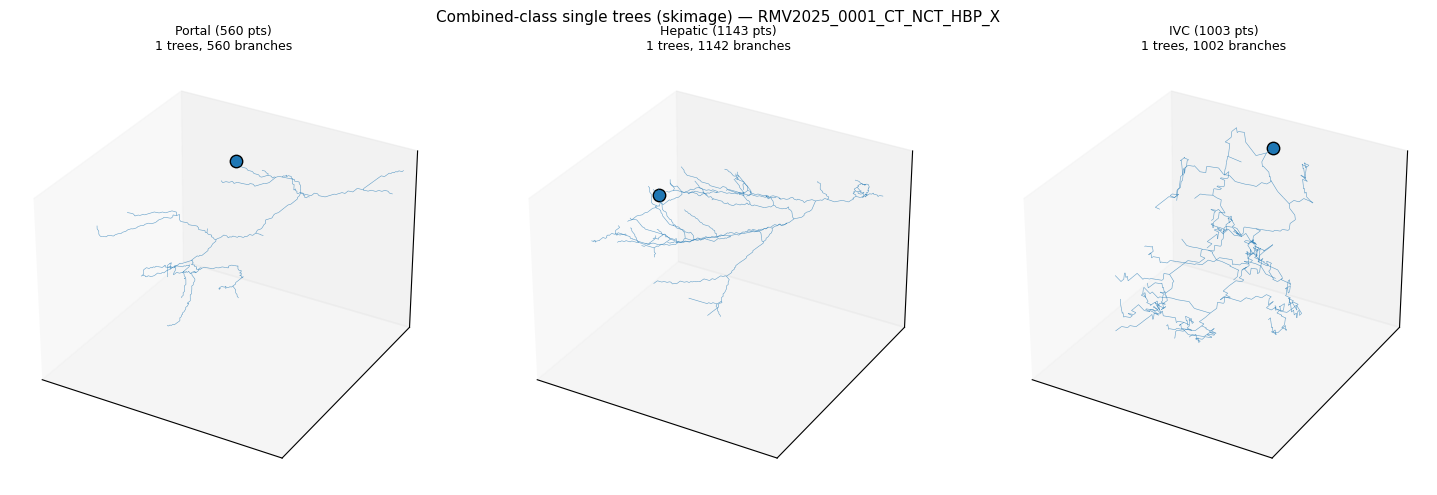

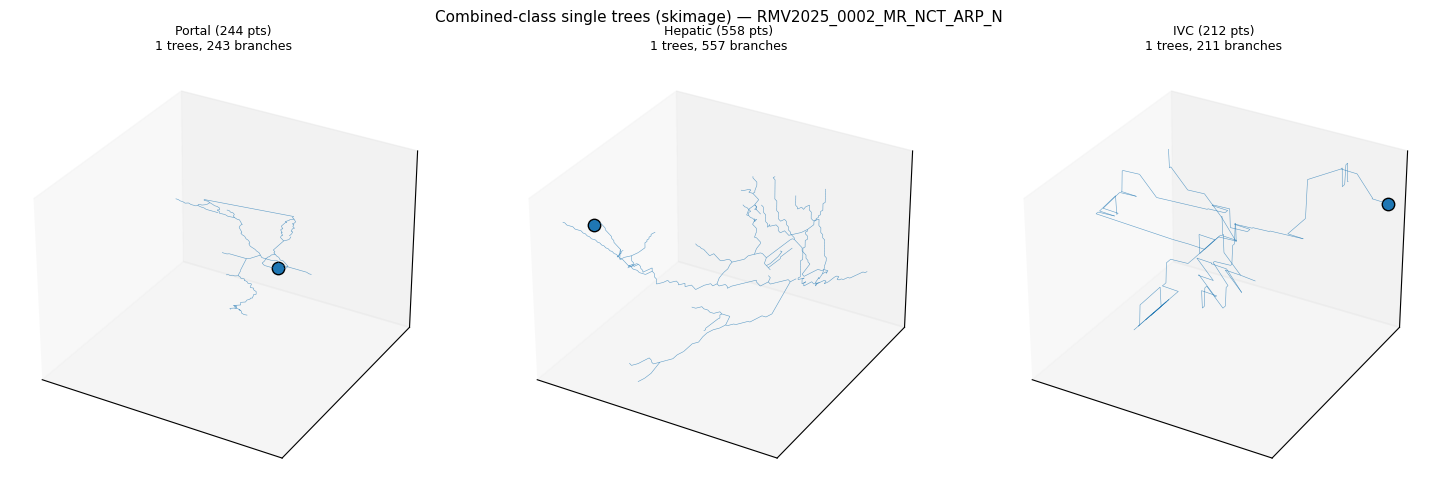

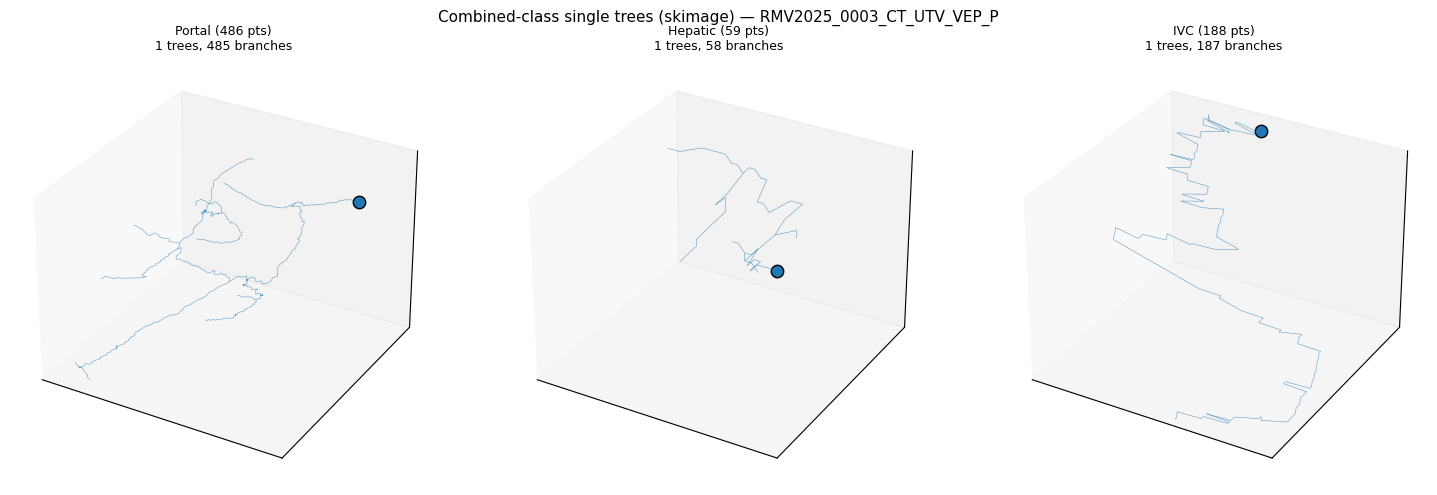

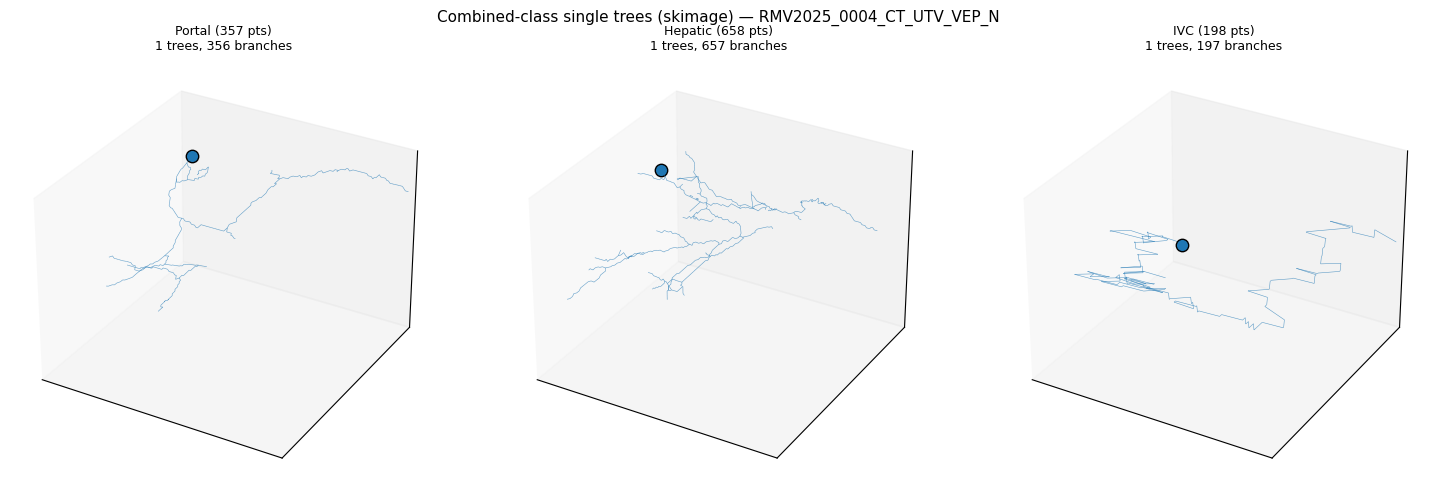

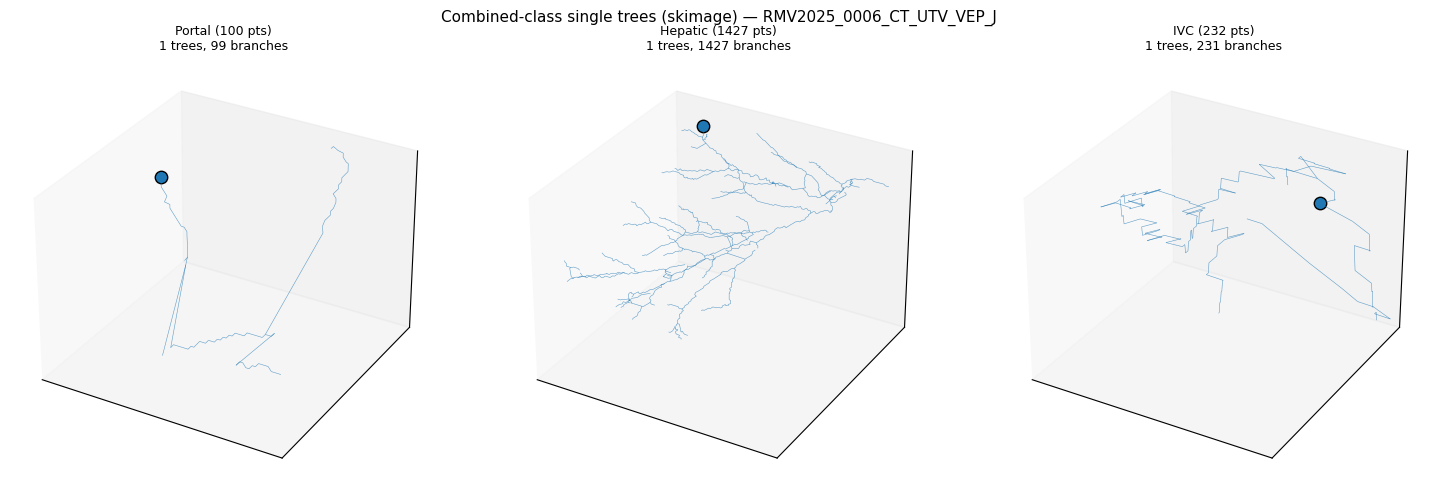

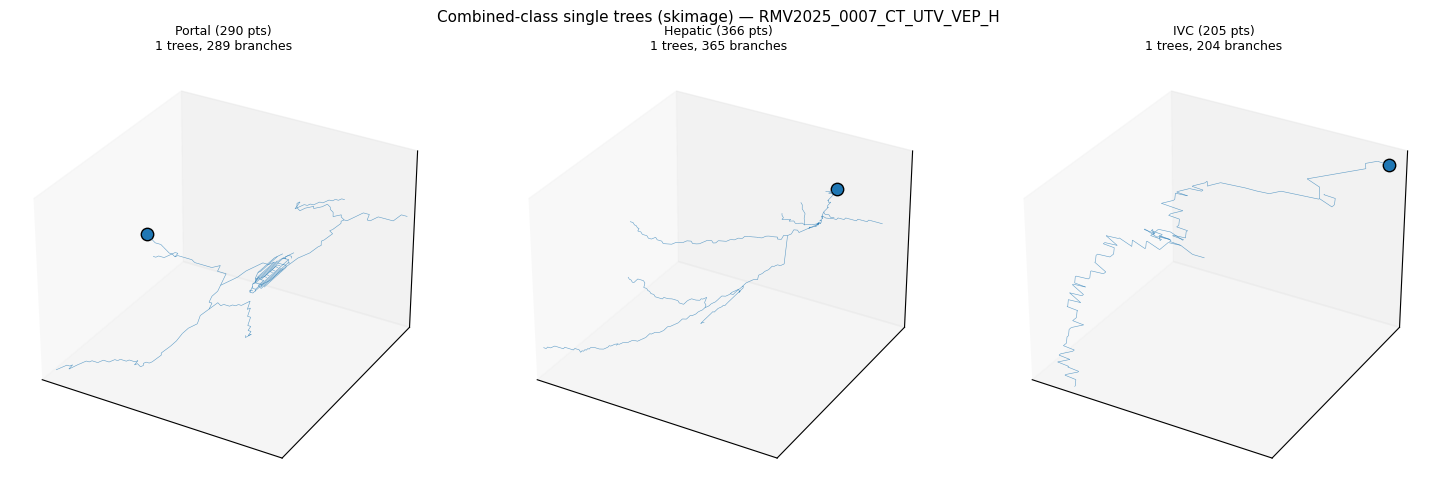

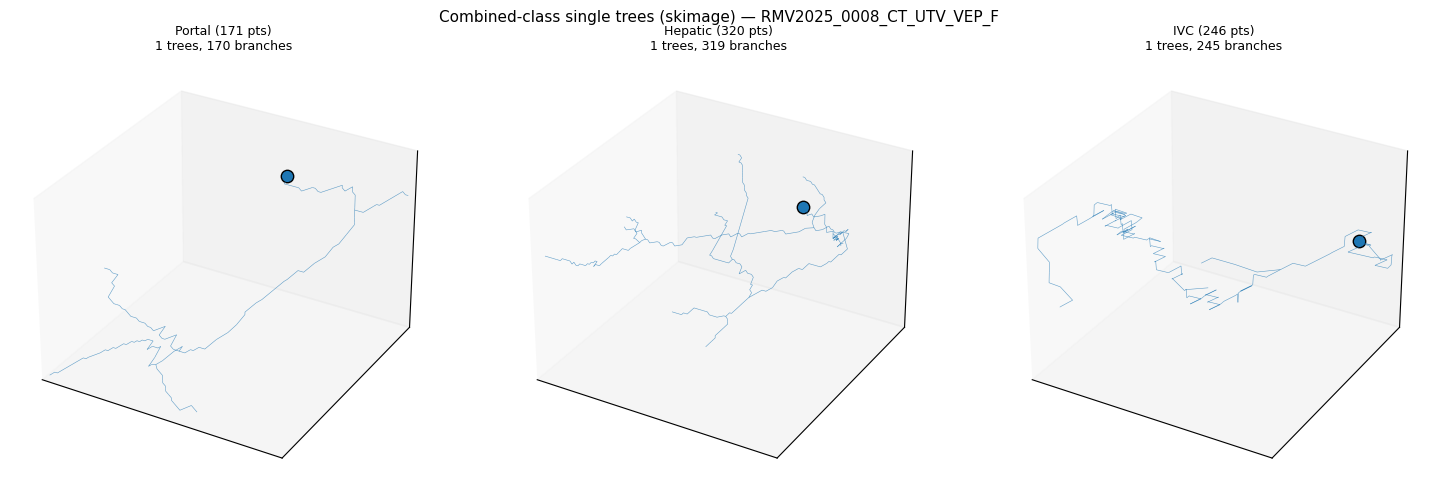

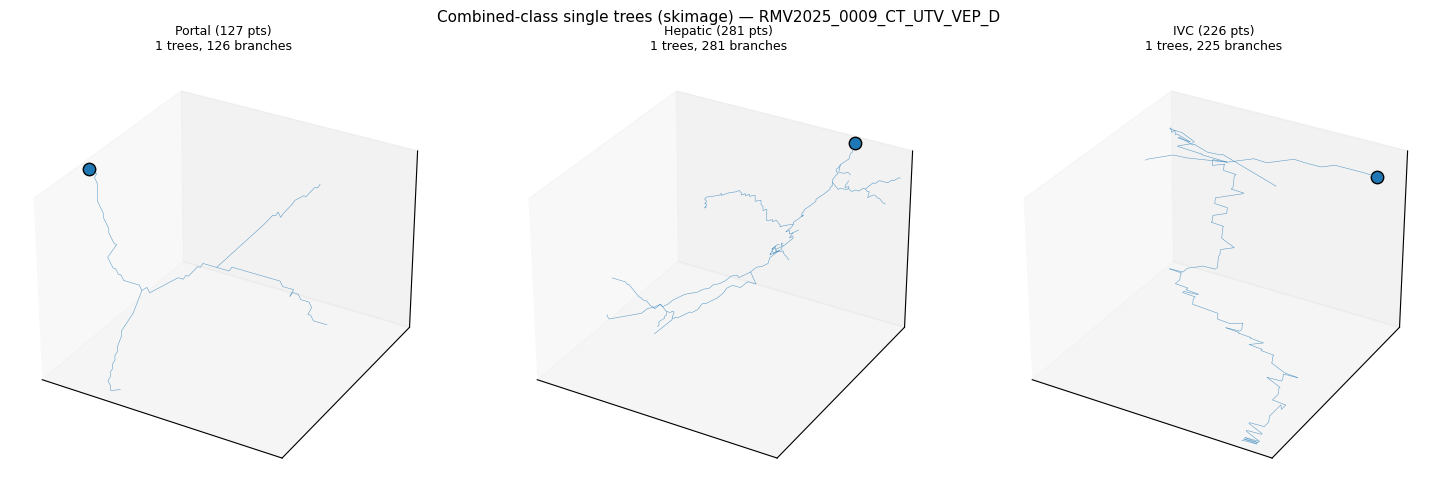

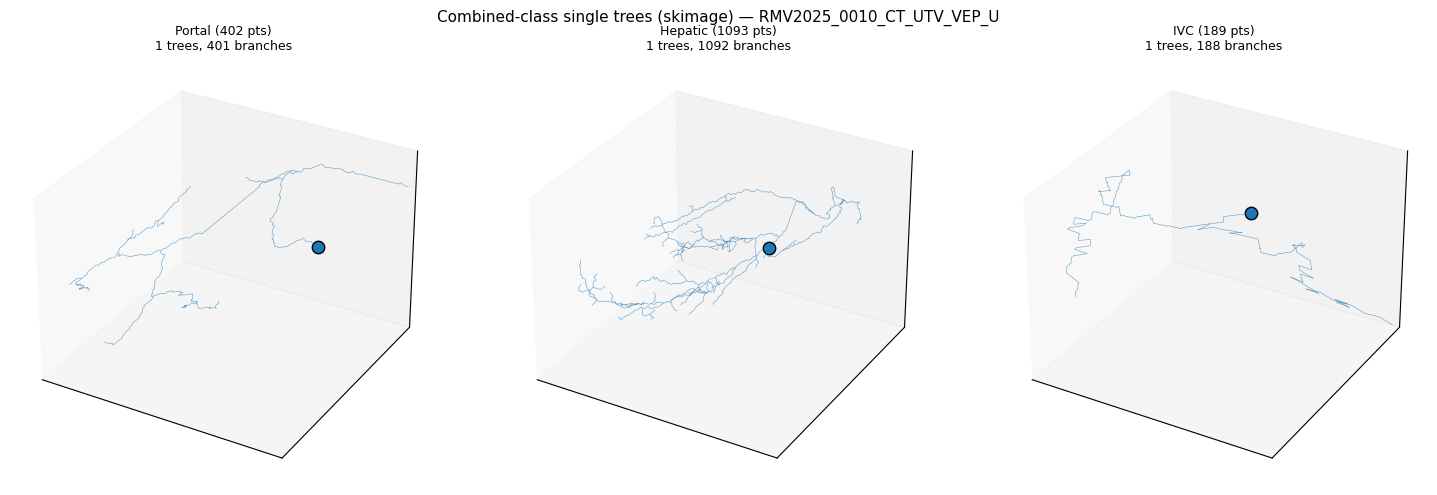

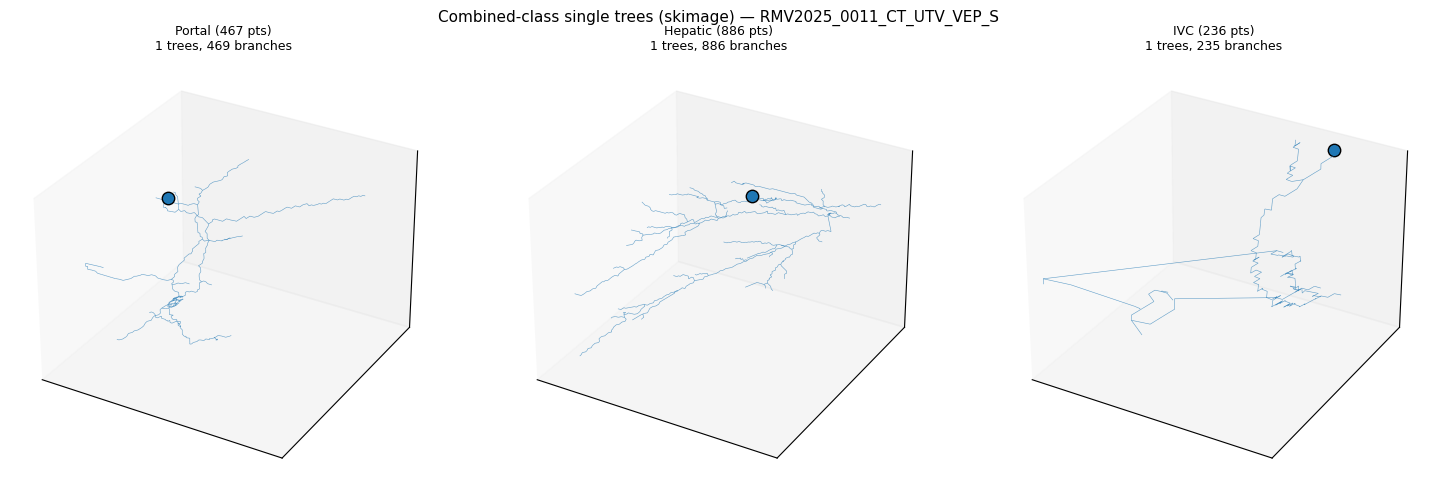

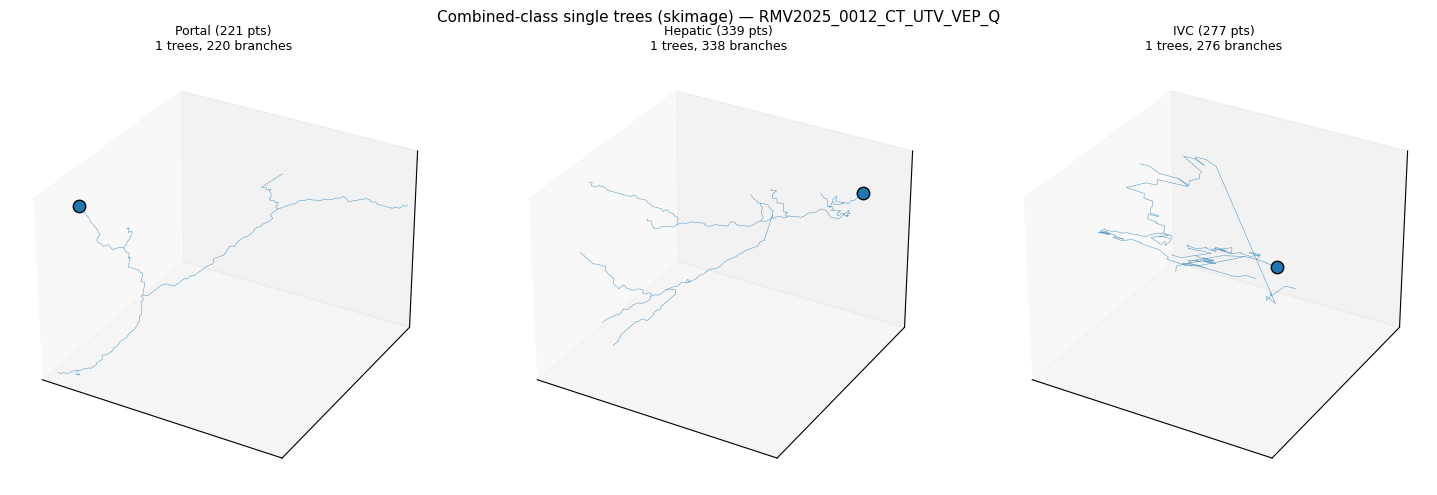

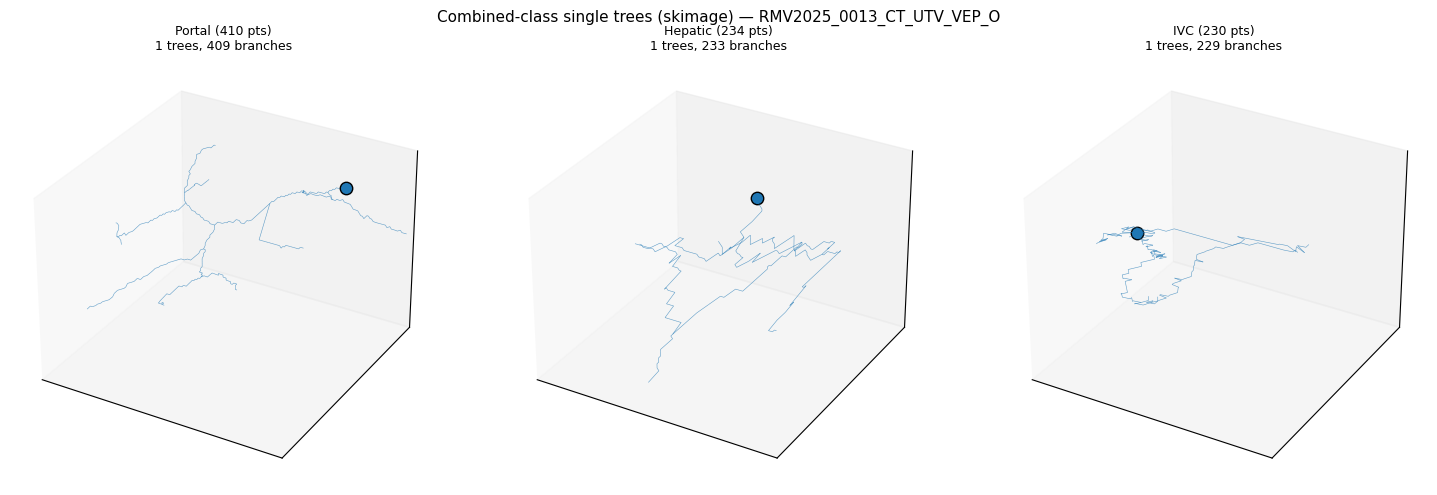

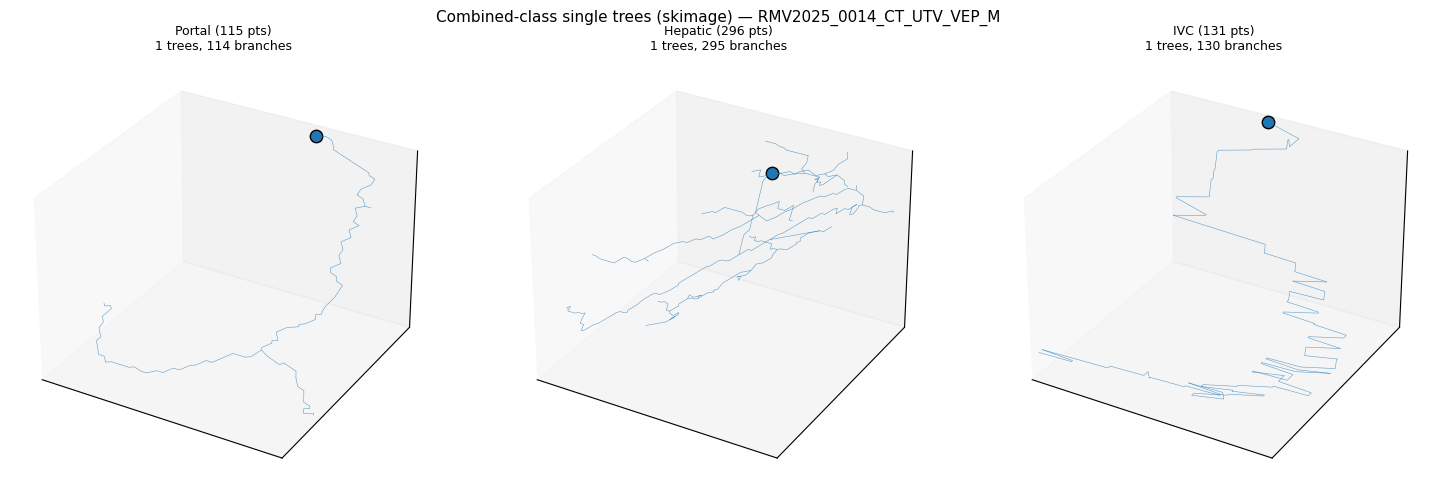

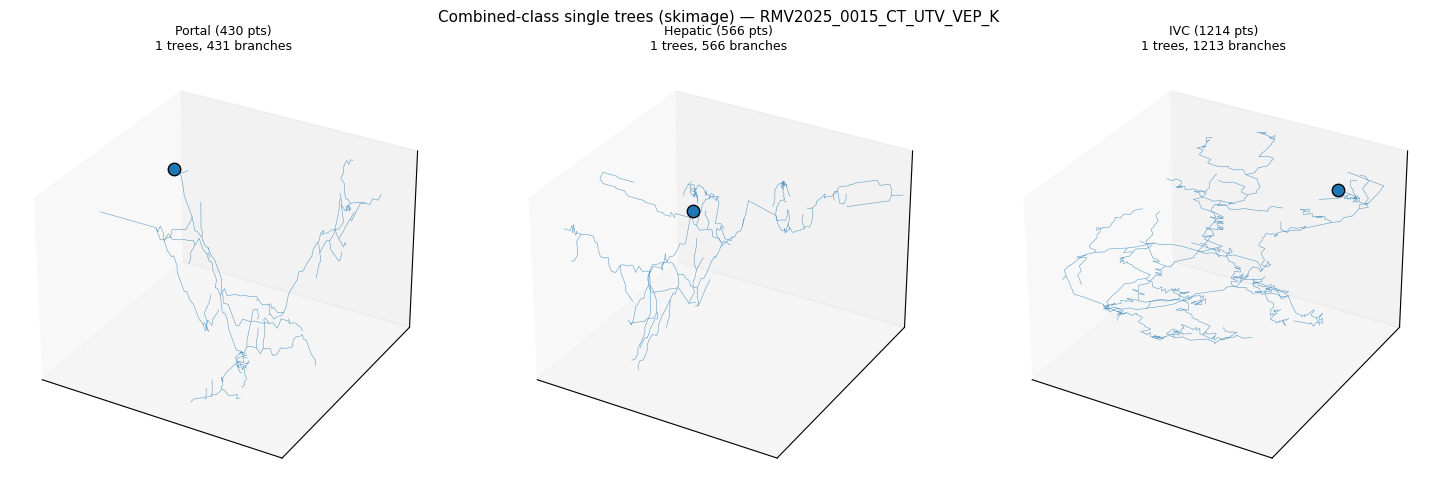

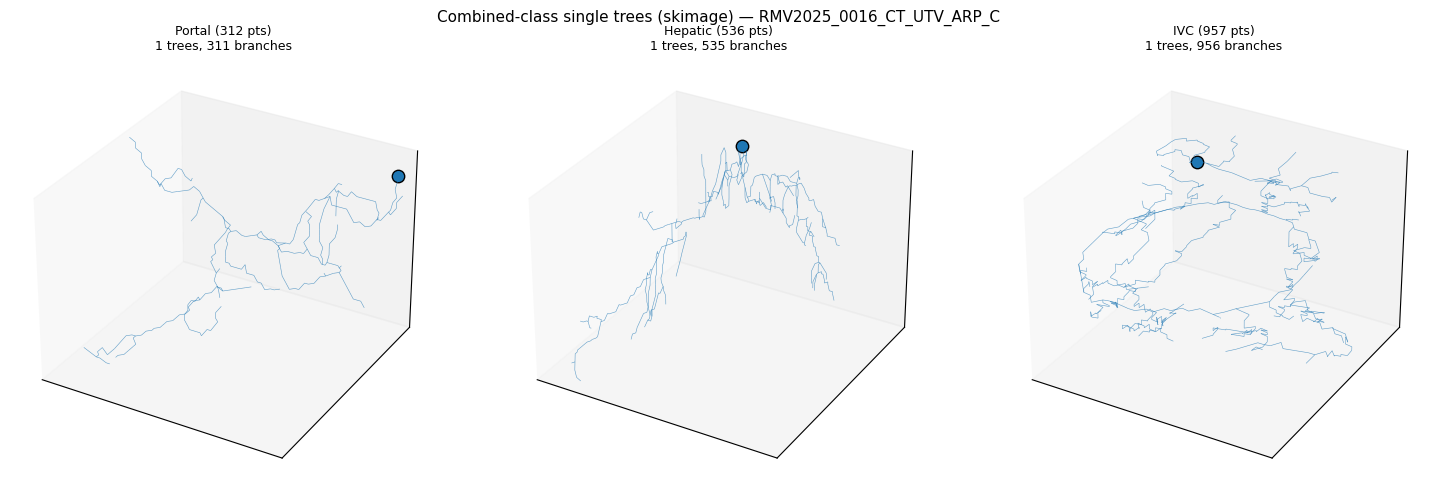

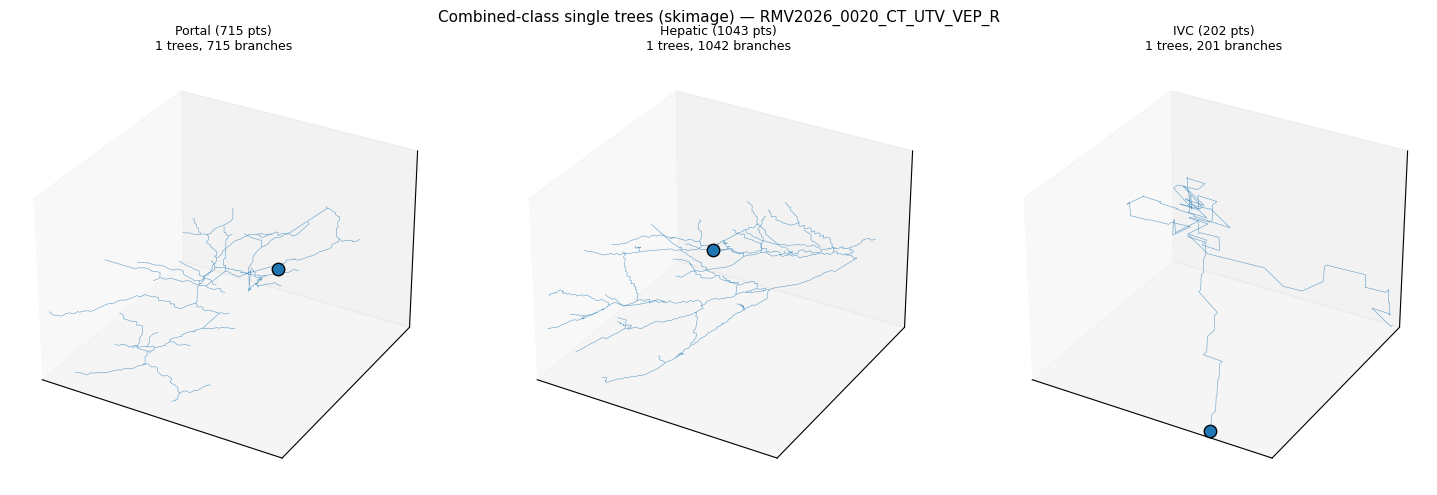

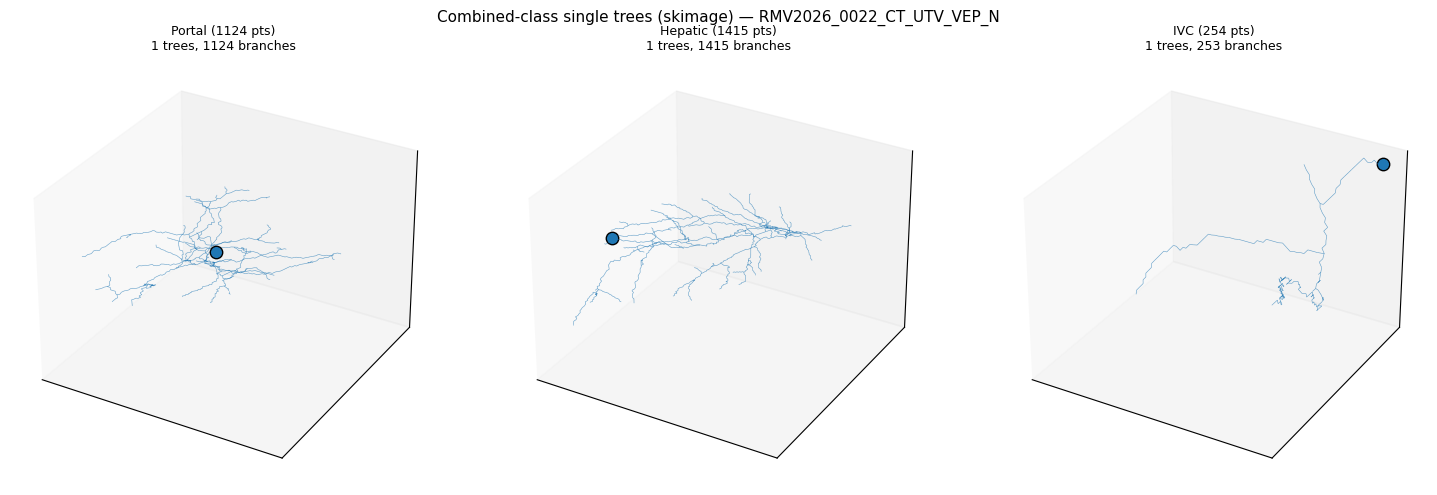

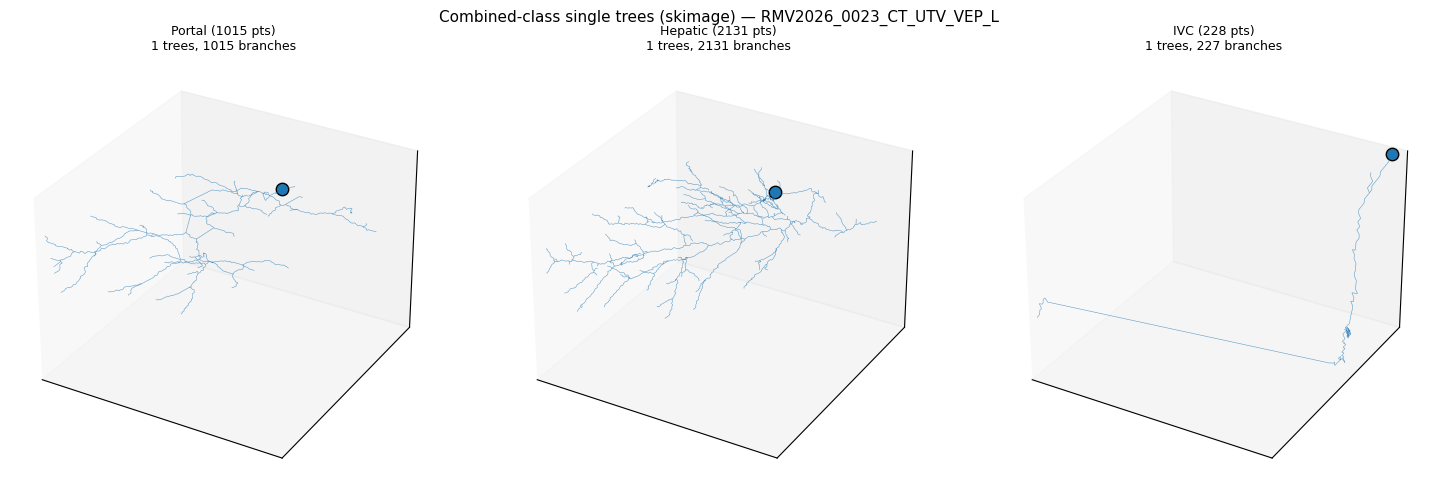

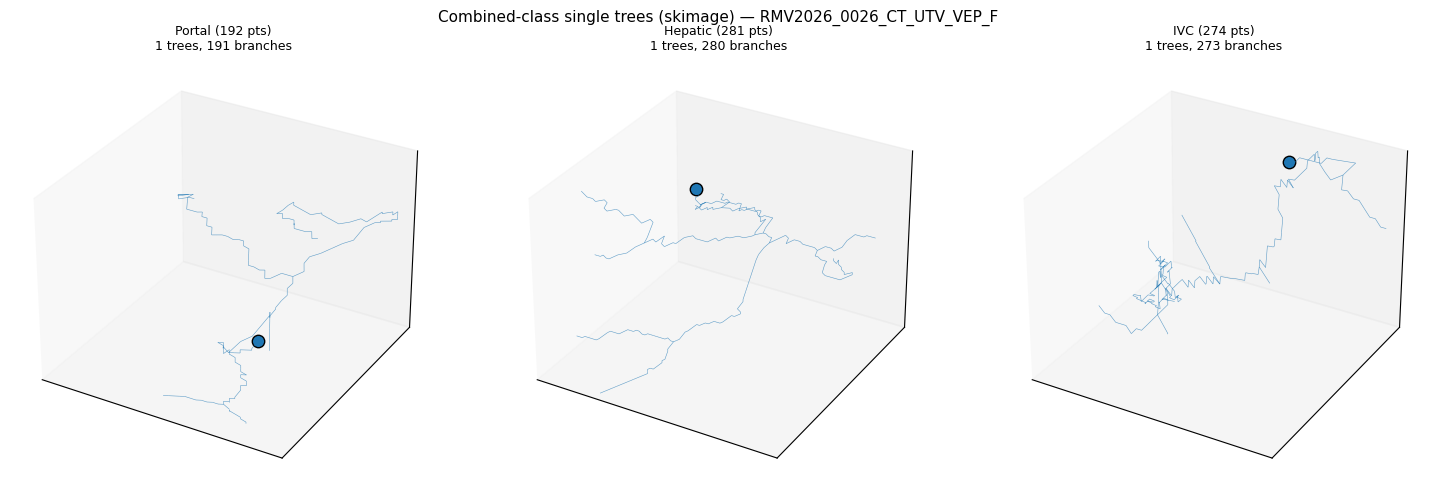

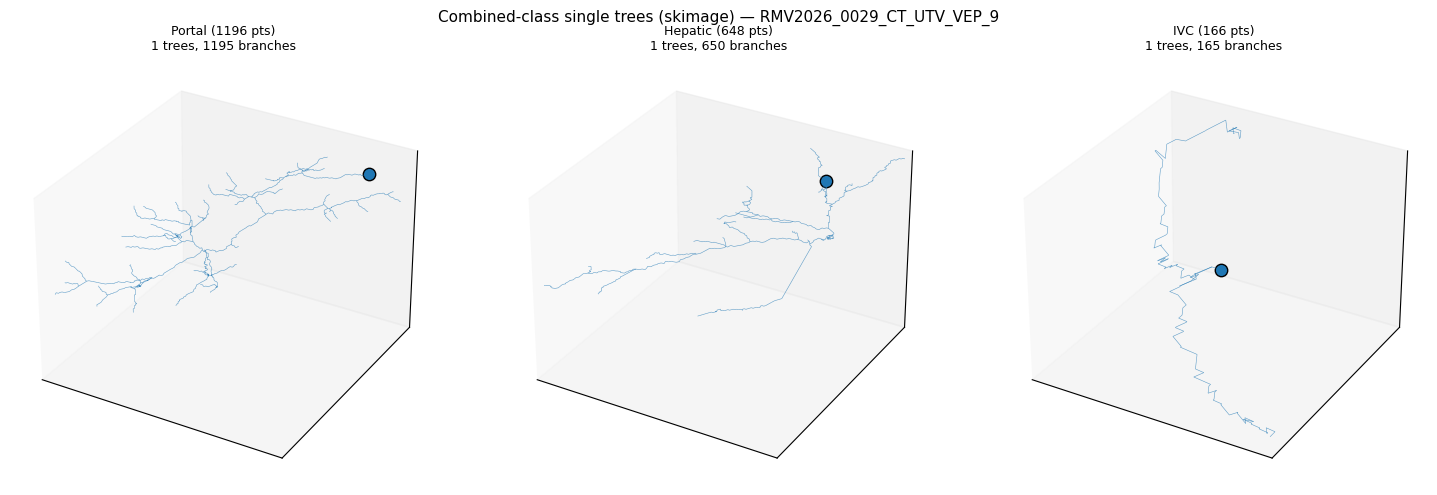

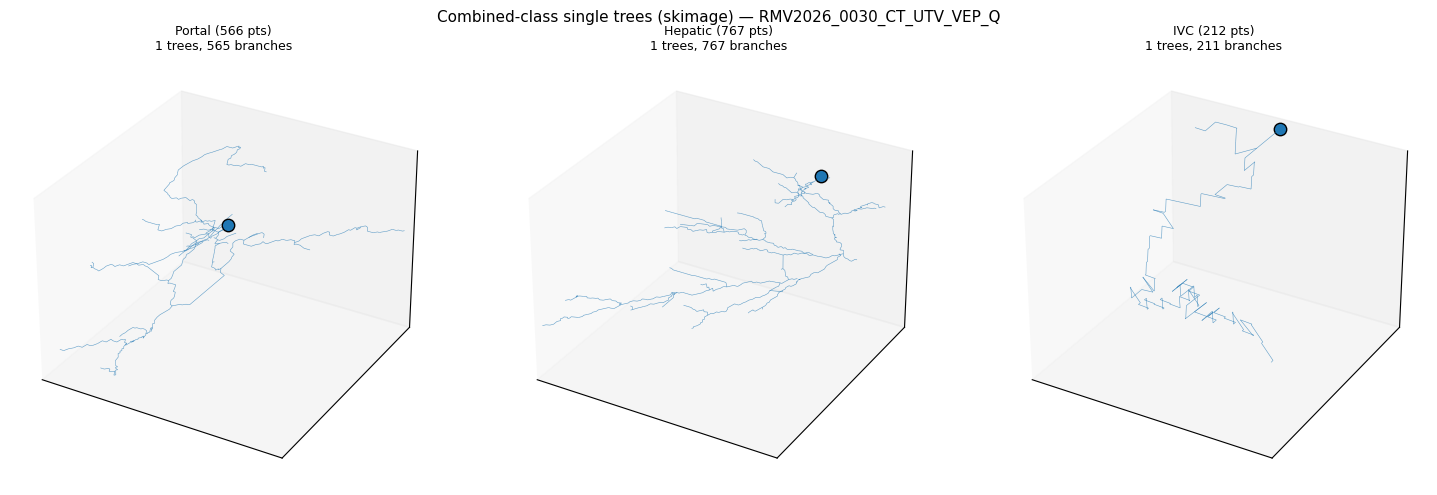

In [67]:
# ---------- visualize: Portal / Hepatic / IVC single trees, per case ----------
STRUCT_COLOR = {'Portal': 'tab:orange', 'Hepatic': 'tab:red', 'IVC': 'tab:blue'}

for c in cases_10:
    case_result = combined_results_10.get(c.name)
    if not case_result:
        continue
    fig = plt.figure(figsize=(15, 5))
    fig.suptitle(f'Combined-class single trees ({SKELETON_METHOD}) — {c.name}', fontsize=11)
    for i, label_name in enumerate(['Portal', 'Hepatic', 'IVC']):
        ax = fig.add_subplot(1, 3, i + 1, projection='3d')
        entry = case_result[label_name]
        if entry['rec'] is not None:
            plot_trees(ax, entry['rec'], f'{label_name} ({len(entry["points"])} pts)')
        elif len(entry['points']):
            plot_points(ax, entry['points'], f'{label_name} ({len(entry["points"])} pts, too few to reconstruct)')
        else:
            ax.set_title(f'{label_name}: empty')
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.tight_layout()
    plt.show()

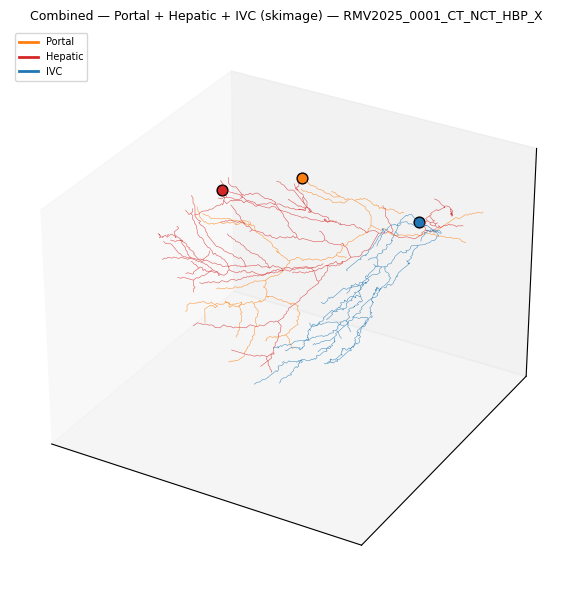

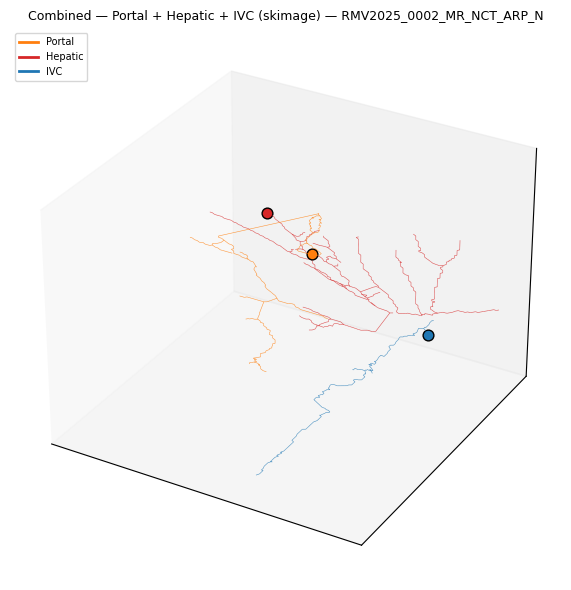

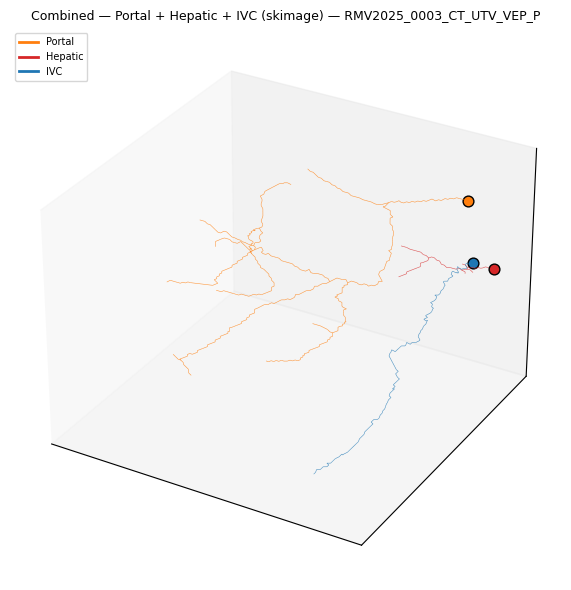

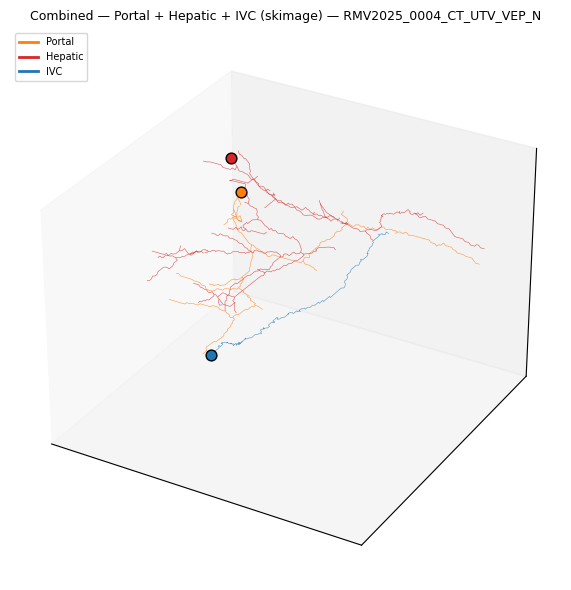

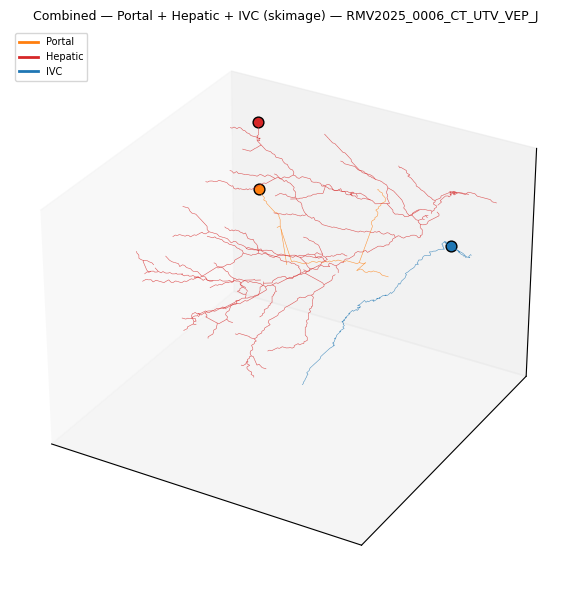

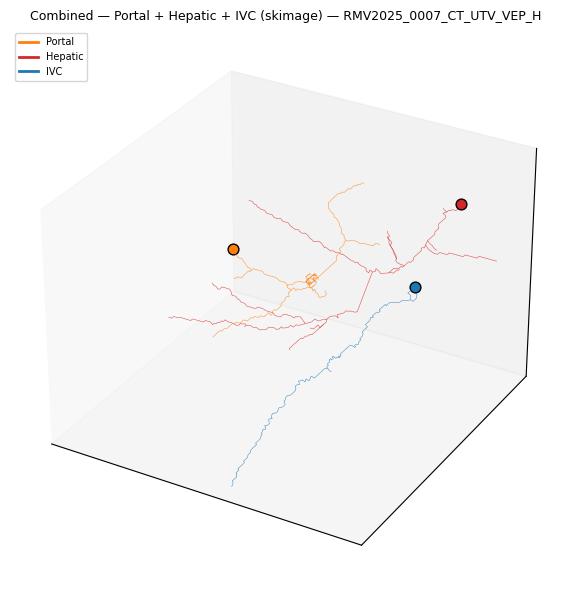

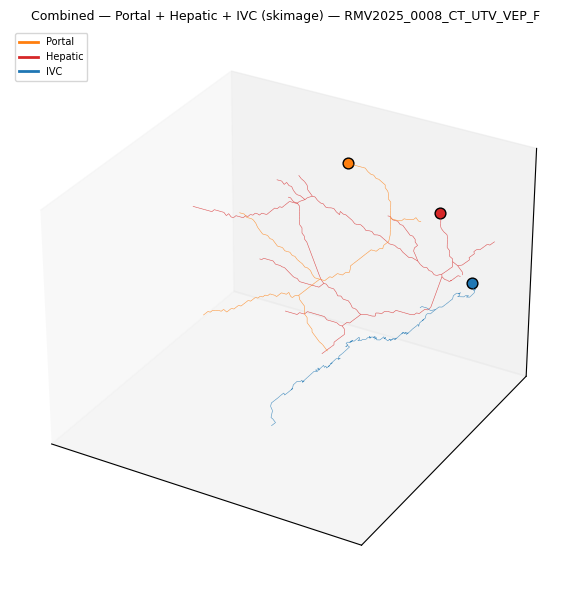

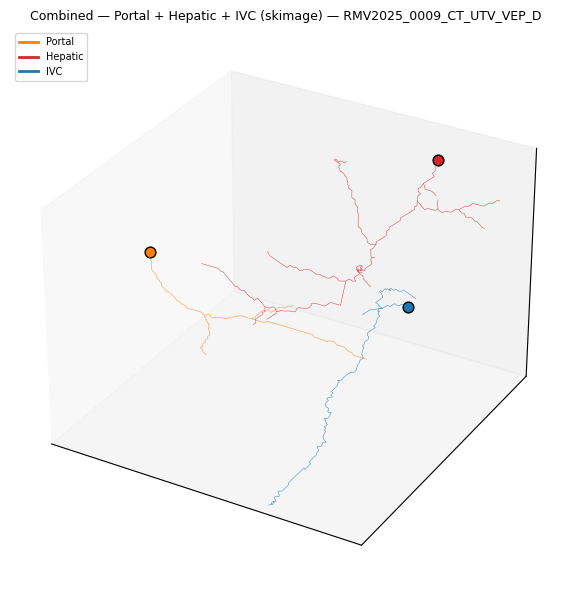

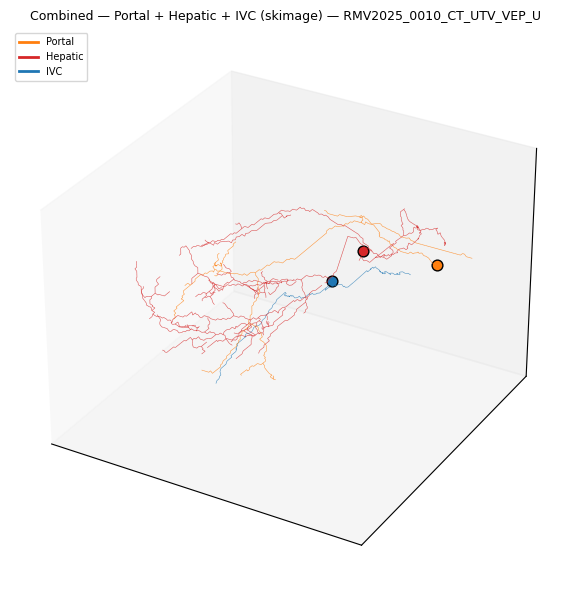

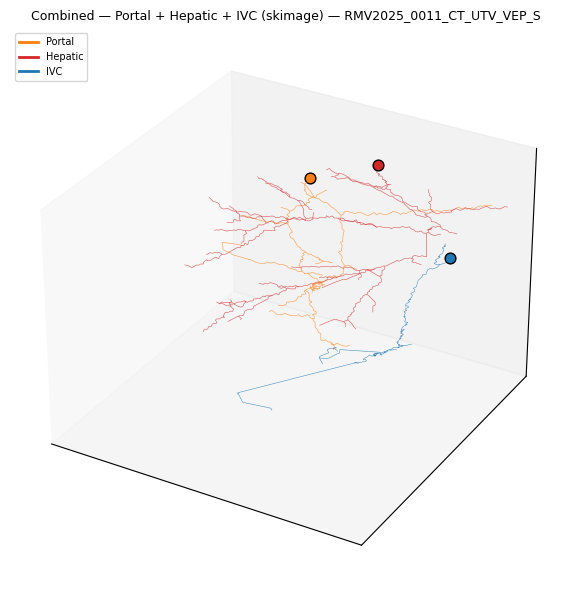

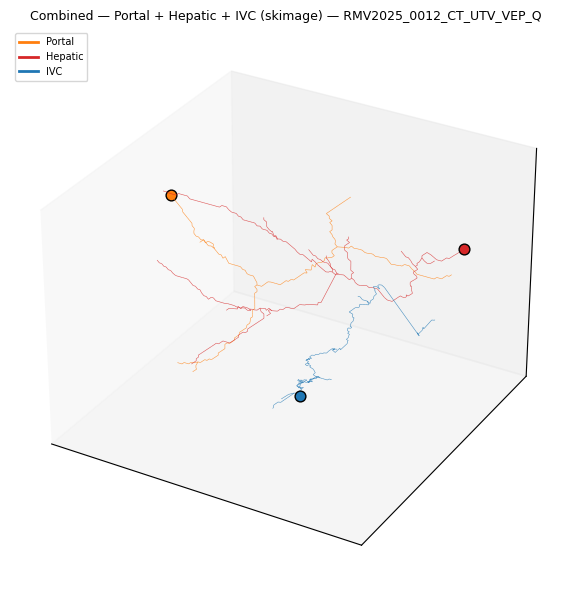

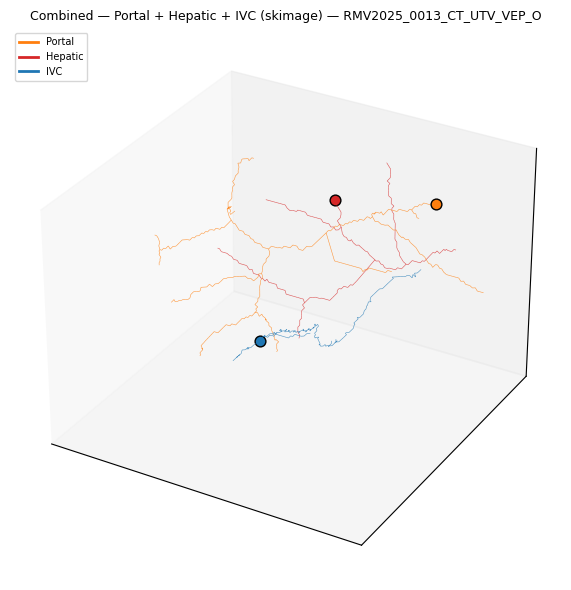

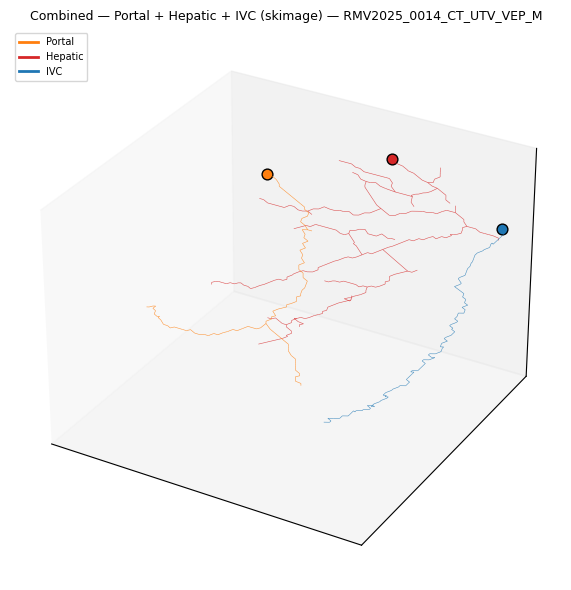

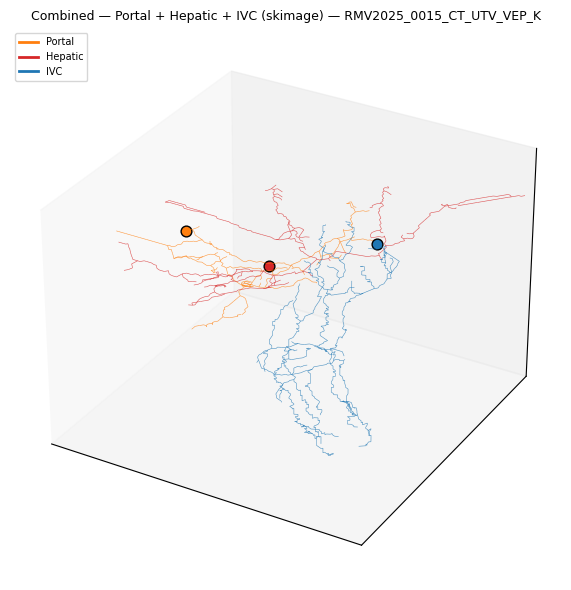

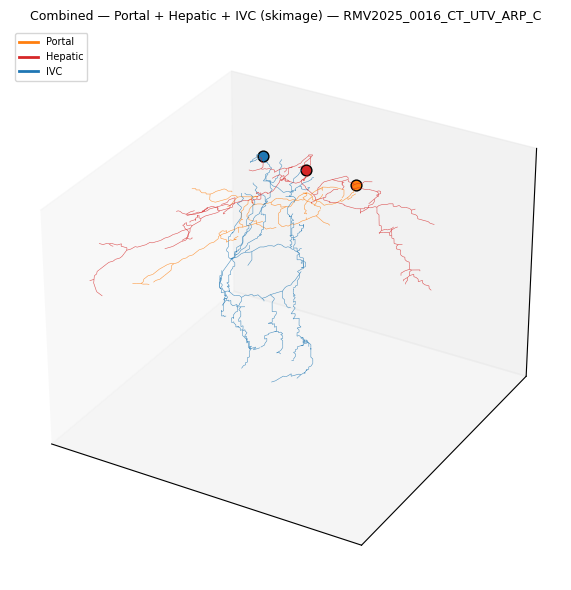

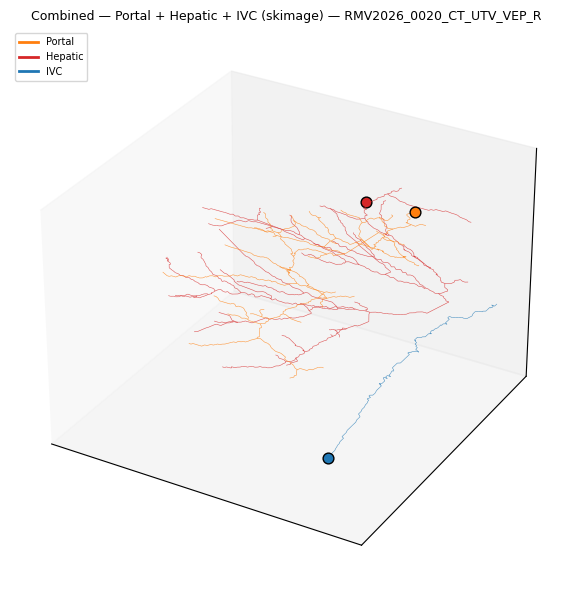

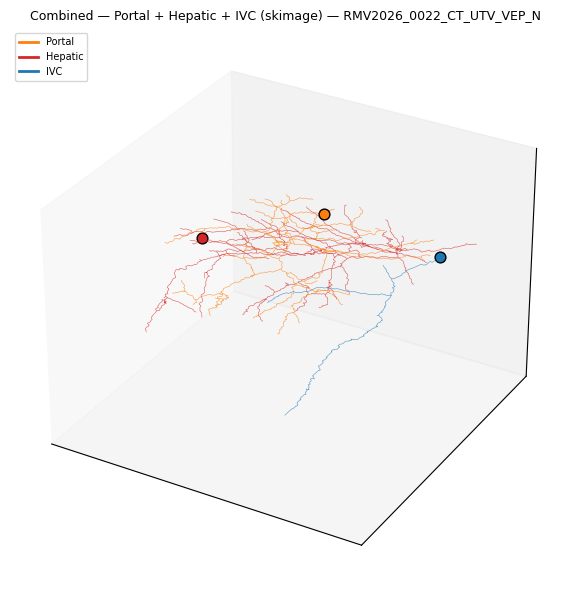

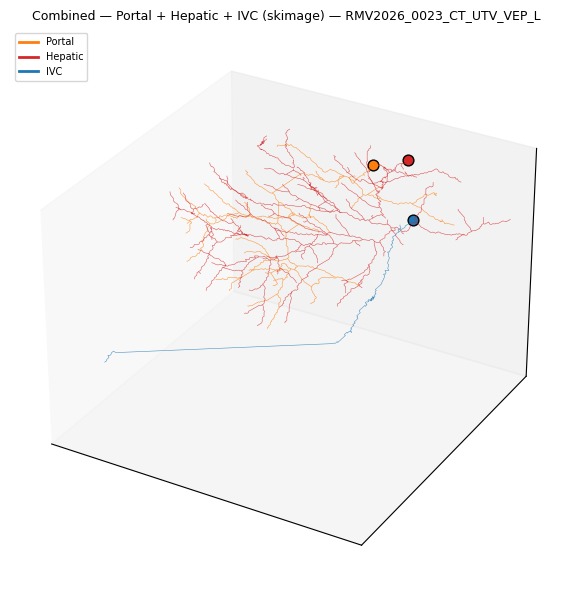

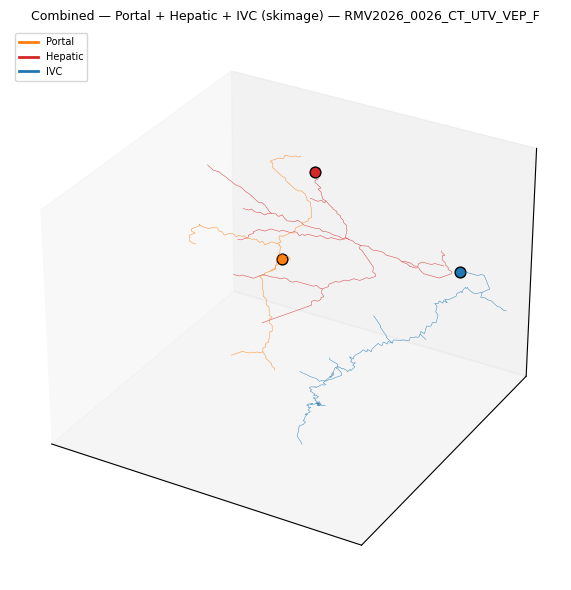

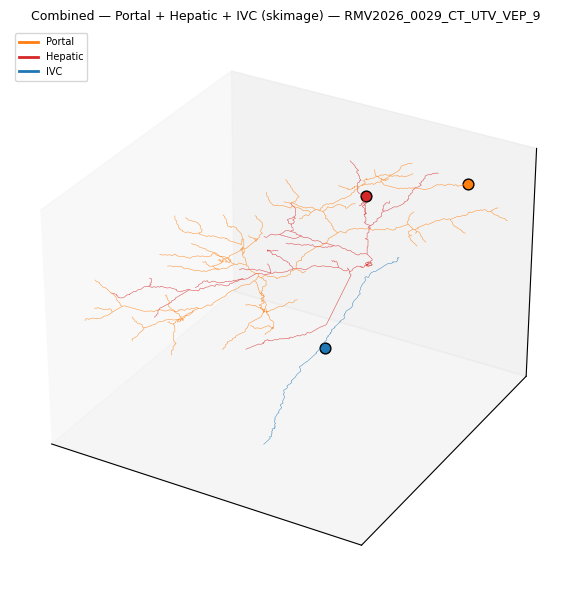

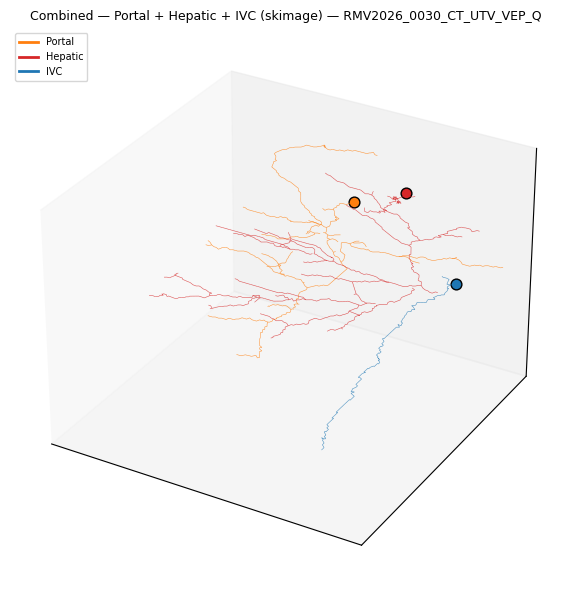

In [68]:
# ---------- combined plot: all 3 skeletons/trees overlaid in one view, per case ----------
from mpl_toolkits.mplot3d.art3d import Line3DCollection as _Line3DCollection

def plot_combined_trees(ax, case_result, title):
    all_pts = []
    for label_name in ['Portal', 'Hepatic', 'IVC']:
        entry = case_result[label_name]
        color = STRUCT_COLOR[label_name]
        rec = entry['rec']
        if rec is not None and rec.trees:
            td = rec.trees[0]
            pts, tree, radii = td['points'], td['tree'], td['radii']
            segs = [(pts[u], pts[v]) for u, v in tree.edges()]
            w = [max(0.4, min(4, radii[v])) for _, v in tree.edges()]
            lc = _Line3DCollection(segs, colors=[color], linewidths=w, alpha=0.8, label=label_name)
            ax.add_collection3d(lc)
            ax.scatter(*pts[td['root']], c=[color], s=60, edgecolors='k', zorder=5)
            all_pts.append(pts)
        elif len(entry['points']):
            pts = entry['points']
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=3, alpha=0.5, color=color, label=label_name)
            all_pts.append(pts)
    if all_pts:
        allp = np.vstack(all_pts)
        ax.set_xlim(allp[:, 0].min(), allp[:, 0].max())
        ax.set_ylim(allp[:, 1].min(), allp[:, 1].max())
        ax.set_zlim(allp[:, 2].min(), allp[:, 2].max())
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    handles = [plt.Line2D([0], [0], color=STRUCT_COLOR[n], lw=2, label=n) for n in ['Portal', 'Hepatic', 'IVC']]
    ax.legend(handles=handles, fontsize=7, loc='upper left')

for c in cases_10:
    case_result = combined_results_10.get(c.name)
    if not case_result:
        continue
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_combined_trees(ax, case_result, f'Combined — Portal + Hepatic + IVC ({SKELETON_METHOD}) — {c.name}')
    plt.tight_layout()
    plt.show()